# Figure 2

Computational panels B–M.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


In [2]:
import importlib.util
import json
from pathlib import Path

import matplotlib as mpl

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

In [3]:
_HERE = ROOT
_ROOT = next((candidate for candidate in (_HERE, *_HERE.parents) if (candidate / 'environment.yml').is_file()))
_DATA_DIR = _ROOT / 'src' / 'manuscript_figures' / 'fig2'
_OUTPUT_DIR = _DATA_DIR / 'generated'
_STYLE = _ROOT / 'src' / 'manuscript_figures' / 'style.mplstyle'
if _STYLE.is_file():
    plt.style.use(_STYLE)
mpl.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 150, 'savefig.dpi': 300, 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'text.parse_math': False})
_flag_style_path = _ROOT / 'src' / 'manuscript_figures' / 'flag_style.py'
_flag_spec = importlib.util.spec_from_file_location('fig2_notebook_flag_style', _flag_style_path)
if _flag_spec is None or _flag_spec.loader is None:
    raise RuntimeError(f'Could not load flag palette from {_flag_style_path}')
_flag_style = importlib.util.module_from_spec(_flag_spec)
_flag_spec.loader.exec_module(_flag_style)
FLAG_ORDER = tuple(_flag_style.FLAG_ORDER)
FLAG_LABELS = dict(_flag_style.FLAG_LABELS)
FLAG_COLORS = dict(_flag_style.flag_colors(cvd_safe=False))
UNFLAGGED_KEY = _flag_style.UNFLAGGED_KEY
UNFLAGGED_COLOR = _flag_style.UNFLAGGED_COLOR
_expected_flag_colors = {'agree': '#6fc46f', 'disagree': '#ec835a', 'inferred': '#c7e1a3', 'no_literature': '#c3c2b7'}
if FLAG_COLORS != _expected_flag_colors:
    raise RuntimeError(f'The shared flag palette drifted from the canonical panel-G colors: {FLAG_COLORS}')
_ARCH_COLORS = {'single': _flag_style.DERIVED_SECONDARY, 'multi': _flag_style.DERIVED_PRIMARY}
_SCOPE_ORDER = ('program_response', 'comparator_relationship', 'expected_program_test', 'cell_group_relationship', 'mixed')
_SCOPE_LABELS = {'program_response': 'Pathway or state change', 'comparator_relationship': 'Perturbation convergence/divergence', 'expected_program_test': 'Prior-prediction outcome', 'cell_group_relationship': 'Cell-group-dependent response', 'mixed': 'Other'}
_SCOPE_COLORS = {'program_response': '#0072B2', 'comparator_relationship': '#56B4E9', 'expected_program_test': '#CC79A7', 'cell_group_relationship': '#F0E442', 'mixed': '#332288'}
_CHROME = {'ink': '#111111', 'muted': '#66645f', 'axis': '#b9b8ae', 'grid': '#e6e5de', 'surface': '#ffffff', 'accessed': '#256abf', 'cited': '#b5407f', 'human': '#eb6834', 'deg': '#6B7075', 'high': '#4C78A8', 'moderate': '#8F6AAE', 'uncovered': _flag_style.NEUTRAL_ABSENT}
_b = pd.read_csv(_DATA_DIR / 'b' / 'union_flag_taxonomy.csv').iloc[:4].copy()
_c_sources = pd.read_csv(_DATA_DIR / 'c' / 'source_access_per_report.csv')
_c_numbers = json.loads((_DATA_DIR / 'c' / 'fig_panelC_analysis.json').read_text(encoding='utf-8'))
_d_numbers = json.loads((_DATA_DIR / 'd' / 'fig_panelC_analysis.json').read_text(encoding='utf-8'))
_scaling = pd.read_csv(_DATA_DIR / 'f' / 'replot_single_vs_multi_layered.csv')
_g_cells = pd.read_csv(_DATA_DIR / 'g' / 'fig2_high_moderate_confidence_heatmap_cells.csv')
_h = pd.read_csv(_DATA_DIR / 'h' / 'final_overall_distribution.csv')
_i = pd.read_csv(_DATA_DIR / 'i' / 'final_finding_scope_distribution.csv')

def _normalize_flag(value):
    if pd.isna(value):
        return ''
    return str(value).strip().casefold().replace(' ', '_')

def _heading(container, letter, title):
    container.suptitle(f'{letter}   {title}', x=0.02, y=0.995, ha='left', va='top', fontsize=10.5, fontweight='bold', color=_CHROME['ink'])

def _clean_axis(ax, grid_axis=None):
    ax.spines[['top', 'right']].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(_CHROME['axis'])
        ax.spines[side].set_linewidth(0.55)
    ax.tick_params(length=2.5, width=0.5, colors=_CHROME['muted'])
    if grid_axis:
        ax.grid(axis=grid_axis, color=_CHROME['grid'], linewidth=0.55)
        ax.set_axisbelow(True)

def _flag_handles():
    return [Patch(facecolor=FLAG_COLORS[key], edgecolor='none', label=FLAG_LABELS[key]) for key in FLAG_ORDER]

NOTEBOOK_SIZE_SCALE = 1.45
NOTEBOOK_FONT_SCALE = 1.15

def save_panel(letter, drawer, size):
    # Paper panels were composed at very small physical sizes.  Give the
    # notebook version more room, then modestly enlarge its typography.
    notebook_size = tuple(value * NOTEBOOK_SIZE_SCALE for value in size)
    figure = plt.figure(figsize=notebook_size)
    drawer(figure)
    for text in figure.findobj(match=mpl.text.Text):
        text.set_fontsize(text.get_fontsize() * NOTEBOOK_FONT_SCALE)
    return (figure, [])
ARCH_COLORS = _ARCH_COLORS
B_DATA = _b
CHROME = _CHROME
C_NUMBERS = _c_numbers
C_SOURCES = _c_sources
D_NUMBERS = _d_numbers
G_CELLS = _g_cells
H_DATA = _h
I_DATA = _i
SCALING = _scaling
SCOPE_COLORS = _SCOPE_COLORS
SCOPE_LABELS = _SCOPE_LABELS
SCOPE_ORDER = _SCOPE_ORDER
clean_axis = _clean_axis
flag_handles = _flag_handles
heading = _heading
normalize_flag = _normalize_flag
output_dir = _OUTPUT_DIR
repo_root = _ROOT

## Figure 2B

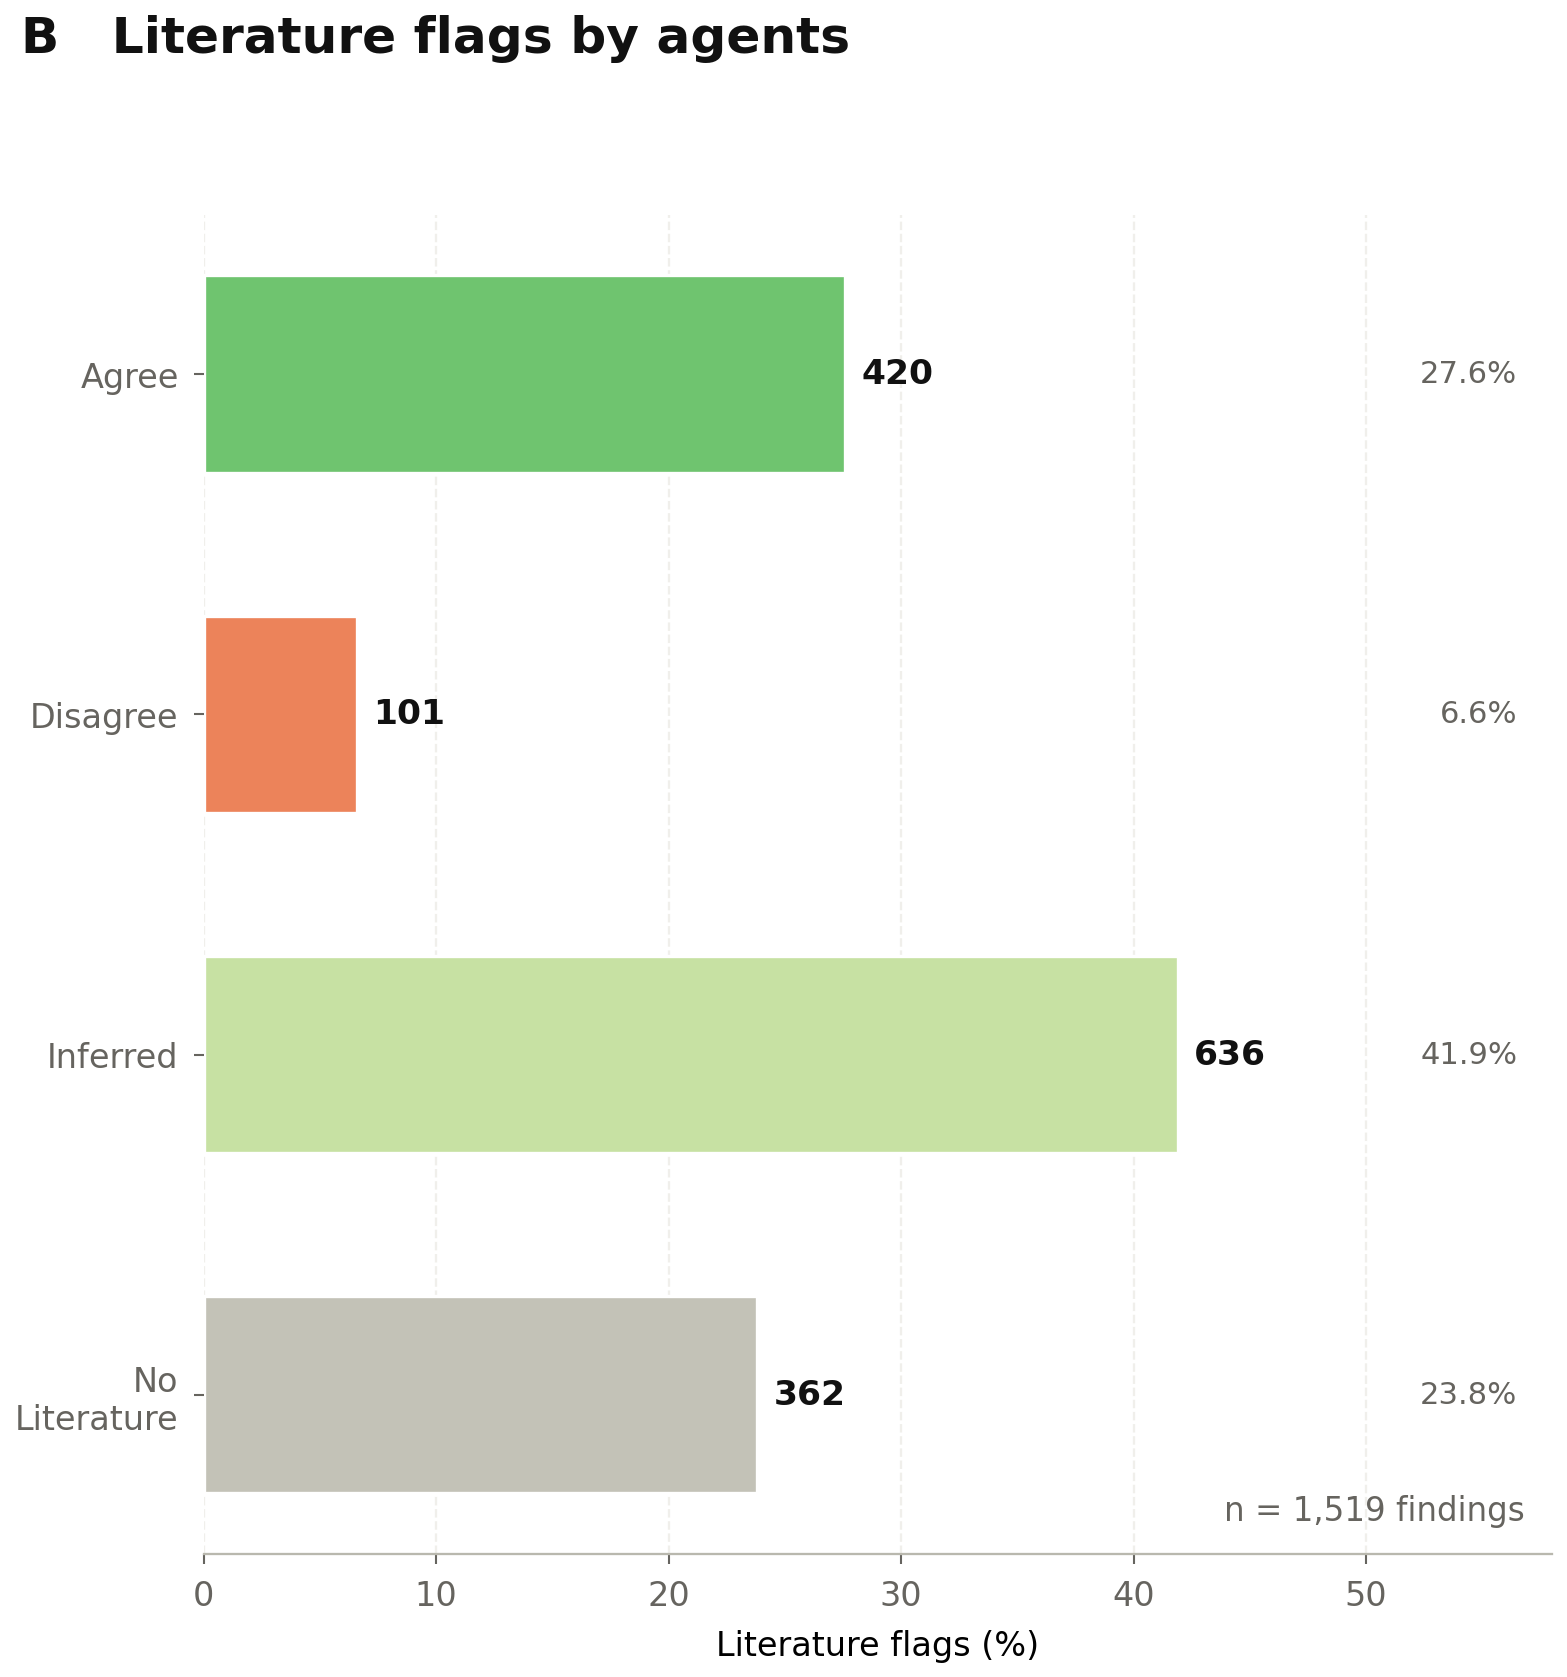

In [4]:
_b = B_DATA
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_normalize_flag = normalize_flag

# ------------------------------------------------------------------ B
def draw_b(container):
    _heading(container, "B", "Literature flags by agents")
    ax = container.subplots()
    frame = _b.assign(key=_b["flag"].map(_normalize_flag)).set_index("key")
    values = [float(frame.loc[key, "percent"]) for key in FLAG_ORDER]
    counts = [int(frame.loc[key, "count"]) for key in FLAG_ORDER]
    labels = [FLAG_LABELS[key].replace("No Literature", "No\nLiterature") for key in FLAG_ORDER]
    y = np.arange(len(FLAG_ORDER))
    ax.barh(
        y,
        values,
        height=0.58,
        color=[FLAG_COLORS[key] for key in FLAG_ORDER],
        edgecolor="white",
        linewidth=0.8,
    )
    for yy, percent, count in zip(y, values, counts):
        ax.text(
            percent + 0.7,
            yy,
            f"{count:,}",
            va="center",
            ha="left",
            fontsize=7.2,
            fontweight="bold",
            color=_CHROME["ink"],
        )
        ax.text(
            56.5,
            yy,
            f"{percent:.1f}%",
            va="center",
            ha="right",
            fontsize=6.4,
            color=_CHROME["muted"],
        )
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 58)
    ax.set_xlabel("Literature flags (%)")
    ax.text(
        0.98,
        0.02,
        f"n = {int(_b.iloc[0]['n_findings']):,} findings",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=6.8,
        color=_CHROME["muted"],
    )
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, colors=_CHROME["ink"])
    _clean_axis(ax, "x")

fig_b, outputs_b = save_panel("B", draw_b, (4.0, 4.0))
fig_b;

## Figure 2C

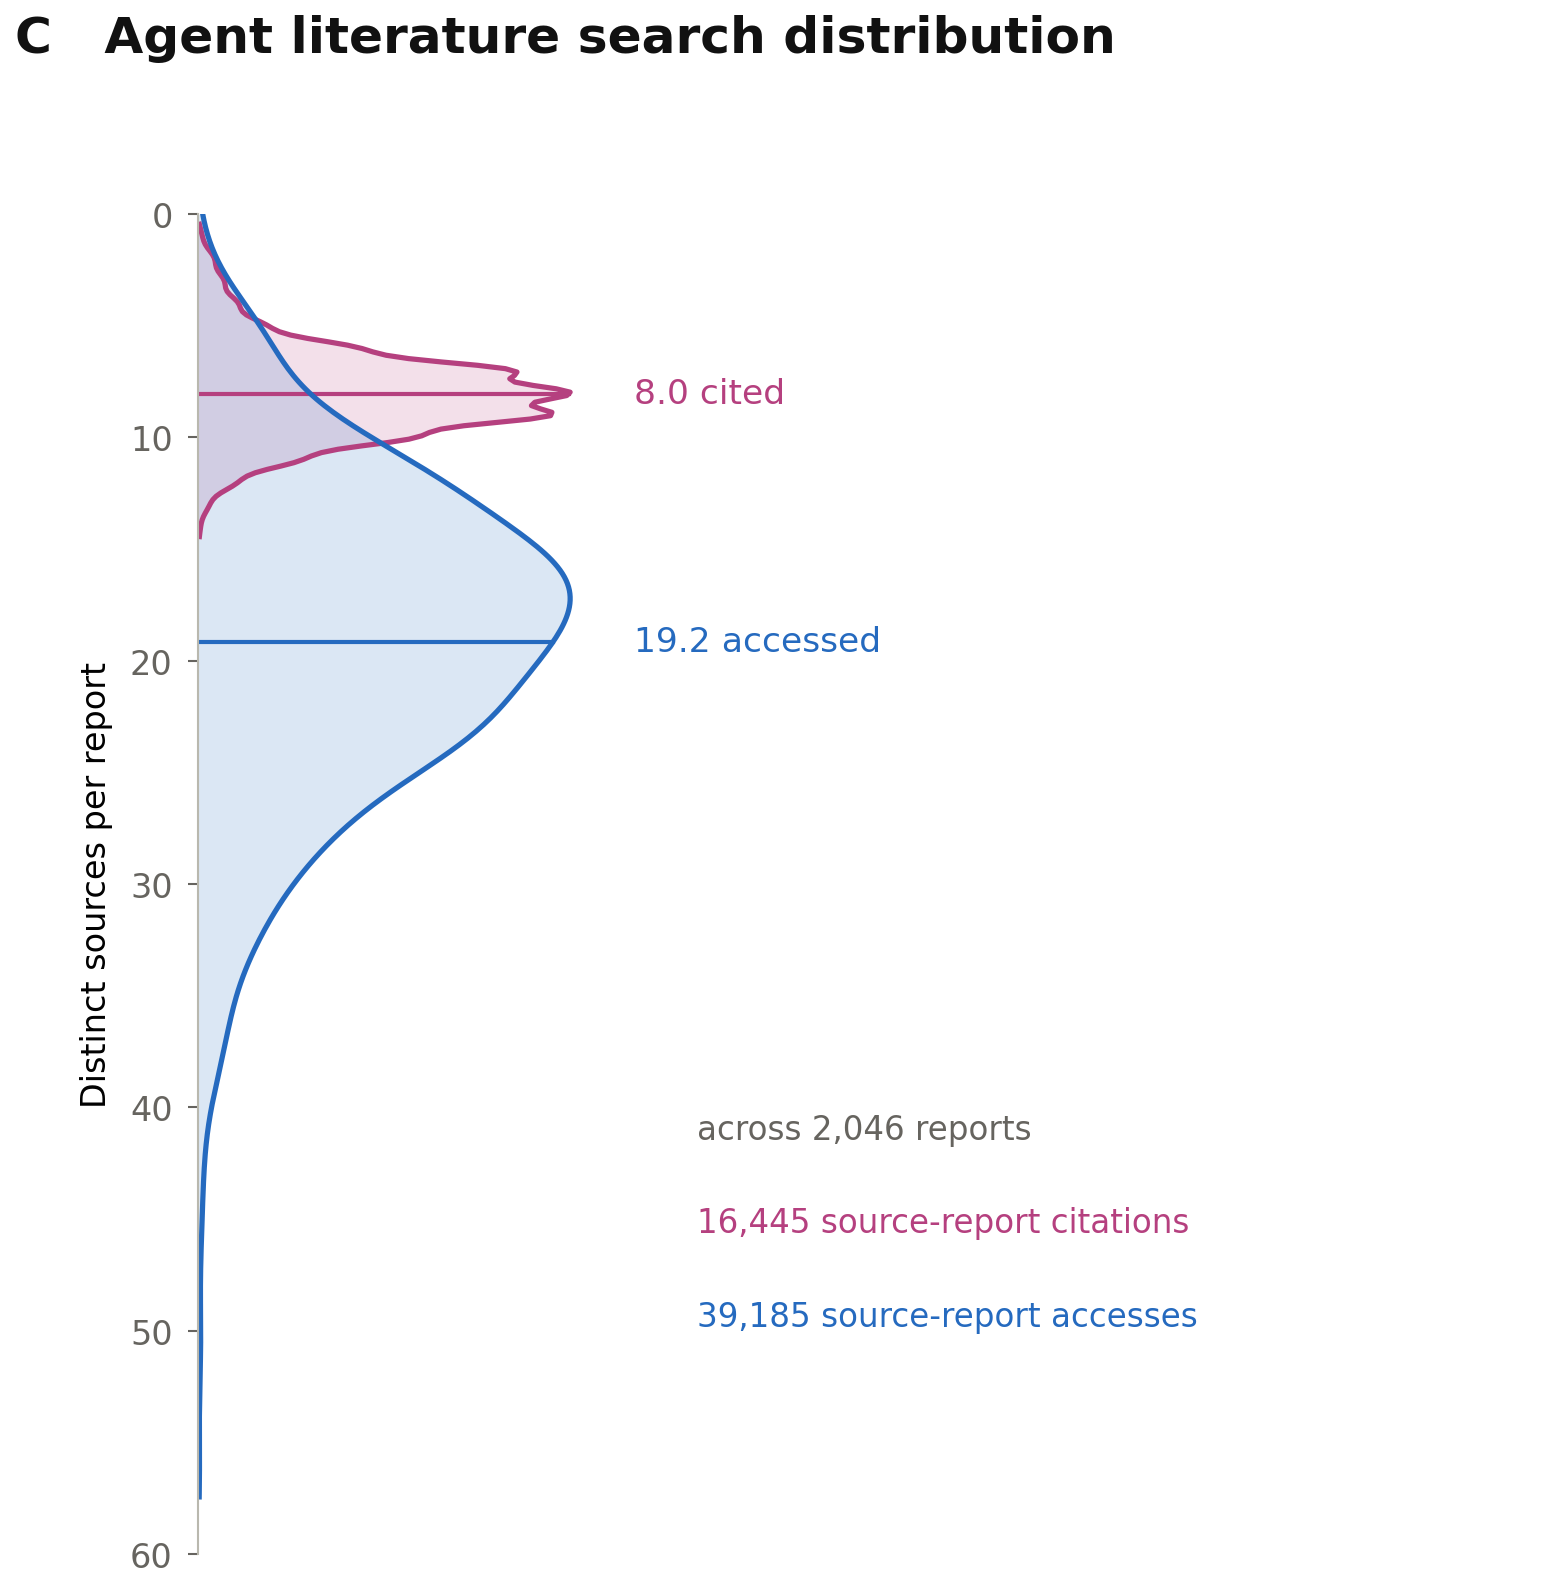

In [5]:
_c_numbers = C_NUMBERS
_c_sources = C_SOURCES
_CHROME = CHROME
_heading = heading

# ------------------------------------------------------------------ C
def draw_c(container):
    _heading(container, "C", "Agent literature search distribution")
    ax = container.subplots()
    grid = np.linspace(0, 60, 400)
    series = (
        (
            _c_sources["cited_sources"].to_numpy(dtype=float),
            "sources cited",
            _CHROME["cited"],
        ),
        (
            _c_sources["accessed_sources"].to_numpy(dtype=float),
            "sources accessed",
            _CHROME["accessed"],
        ),
    )
    for raw, label, color in series:
        density = gaussian_kde(raw)(grid)
        density /= density.max()
        width = density * 0.29
        keep = density > 0.004
        ax.fill_betweenx(grid[keep], 0, width[keep], color=color, alpha=0.16, lw=0)
        ax.plot(width[keep], grid[keep], color=color, lw=1.25)
        mean = float(raw.mean())
        mean_width = float(np.interp(mean, grid, width))
        ax.plot([0, mean_width], [mean, mean], color=color, lw=1.0)
        ax.text(
            0.34,
            mean,
            f"{mean:.1f} {label.removeprefix('sources ')}",
            fontsize=7.2,
            color=color,
            ha="left",
            va="center",
        )
    ax.text(
        0.37,
        0.31,
        f"across {_c_numbers['n']:,} reports",
        transform=ax.transAxes,
        fontsize=6.8,
        color=_CHROME["muted"],
    )
    ax.text(
        0.37,
        0.24,
        f"{_c_numbers['cited_total']:,} source-report citations",
        transform=ax.transAxes,
        fontsize=6.8,
        color=_CHROME["cited"],
    )
    ax.text(
        0.37,
        0.17,
        f"{_c_numbers['accessed_total']:,} source-report accesses",
        transform=ax.transAxes,
        fontsize=6.8,
        color=_CHROME["accessed"],
    )
    ax.set_xlim(0, 1.05)
    ax.set_ylim(60, 0)
    ax.set_xticks([])
    ax.set_yticks(np.arange(0, 61, 10))
    ax.set_ylabel("Distinct sources per report")
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_color(_CHROME["axis"])
    ax.tick_params(axis="y", length=2.5, width=0.5, colors=_CHROME["muted"])

fig_c, outputs_c = save_panel("C", draw_c, (4.0, 4.0))
fig_c;

## Figure 2D

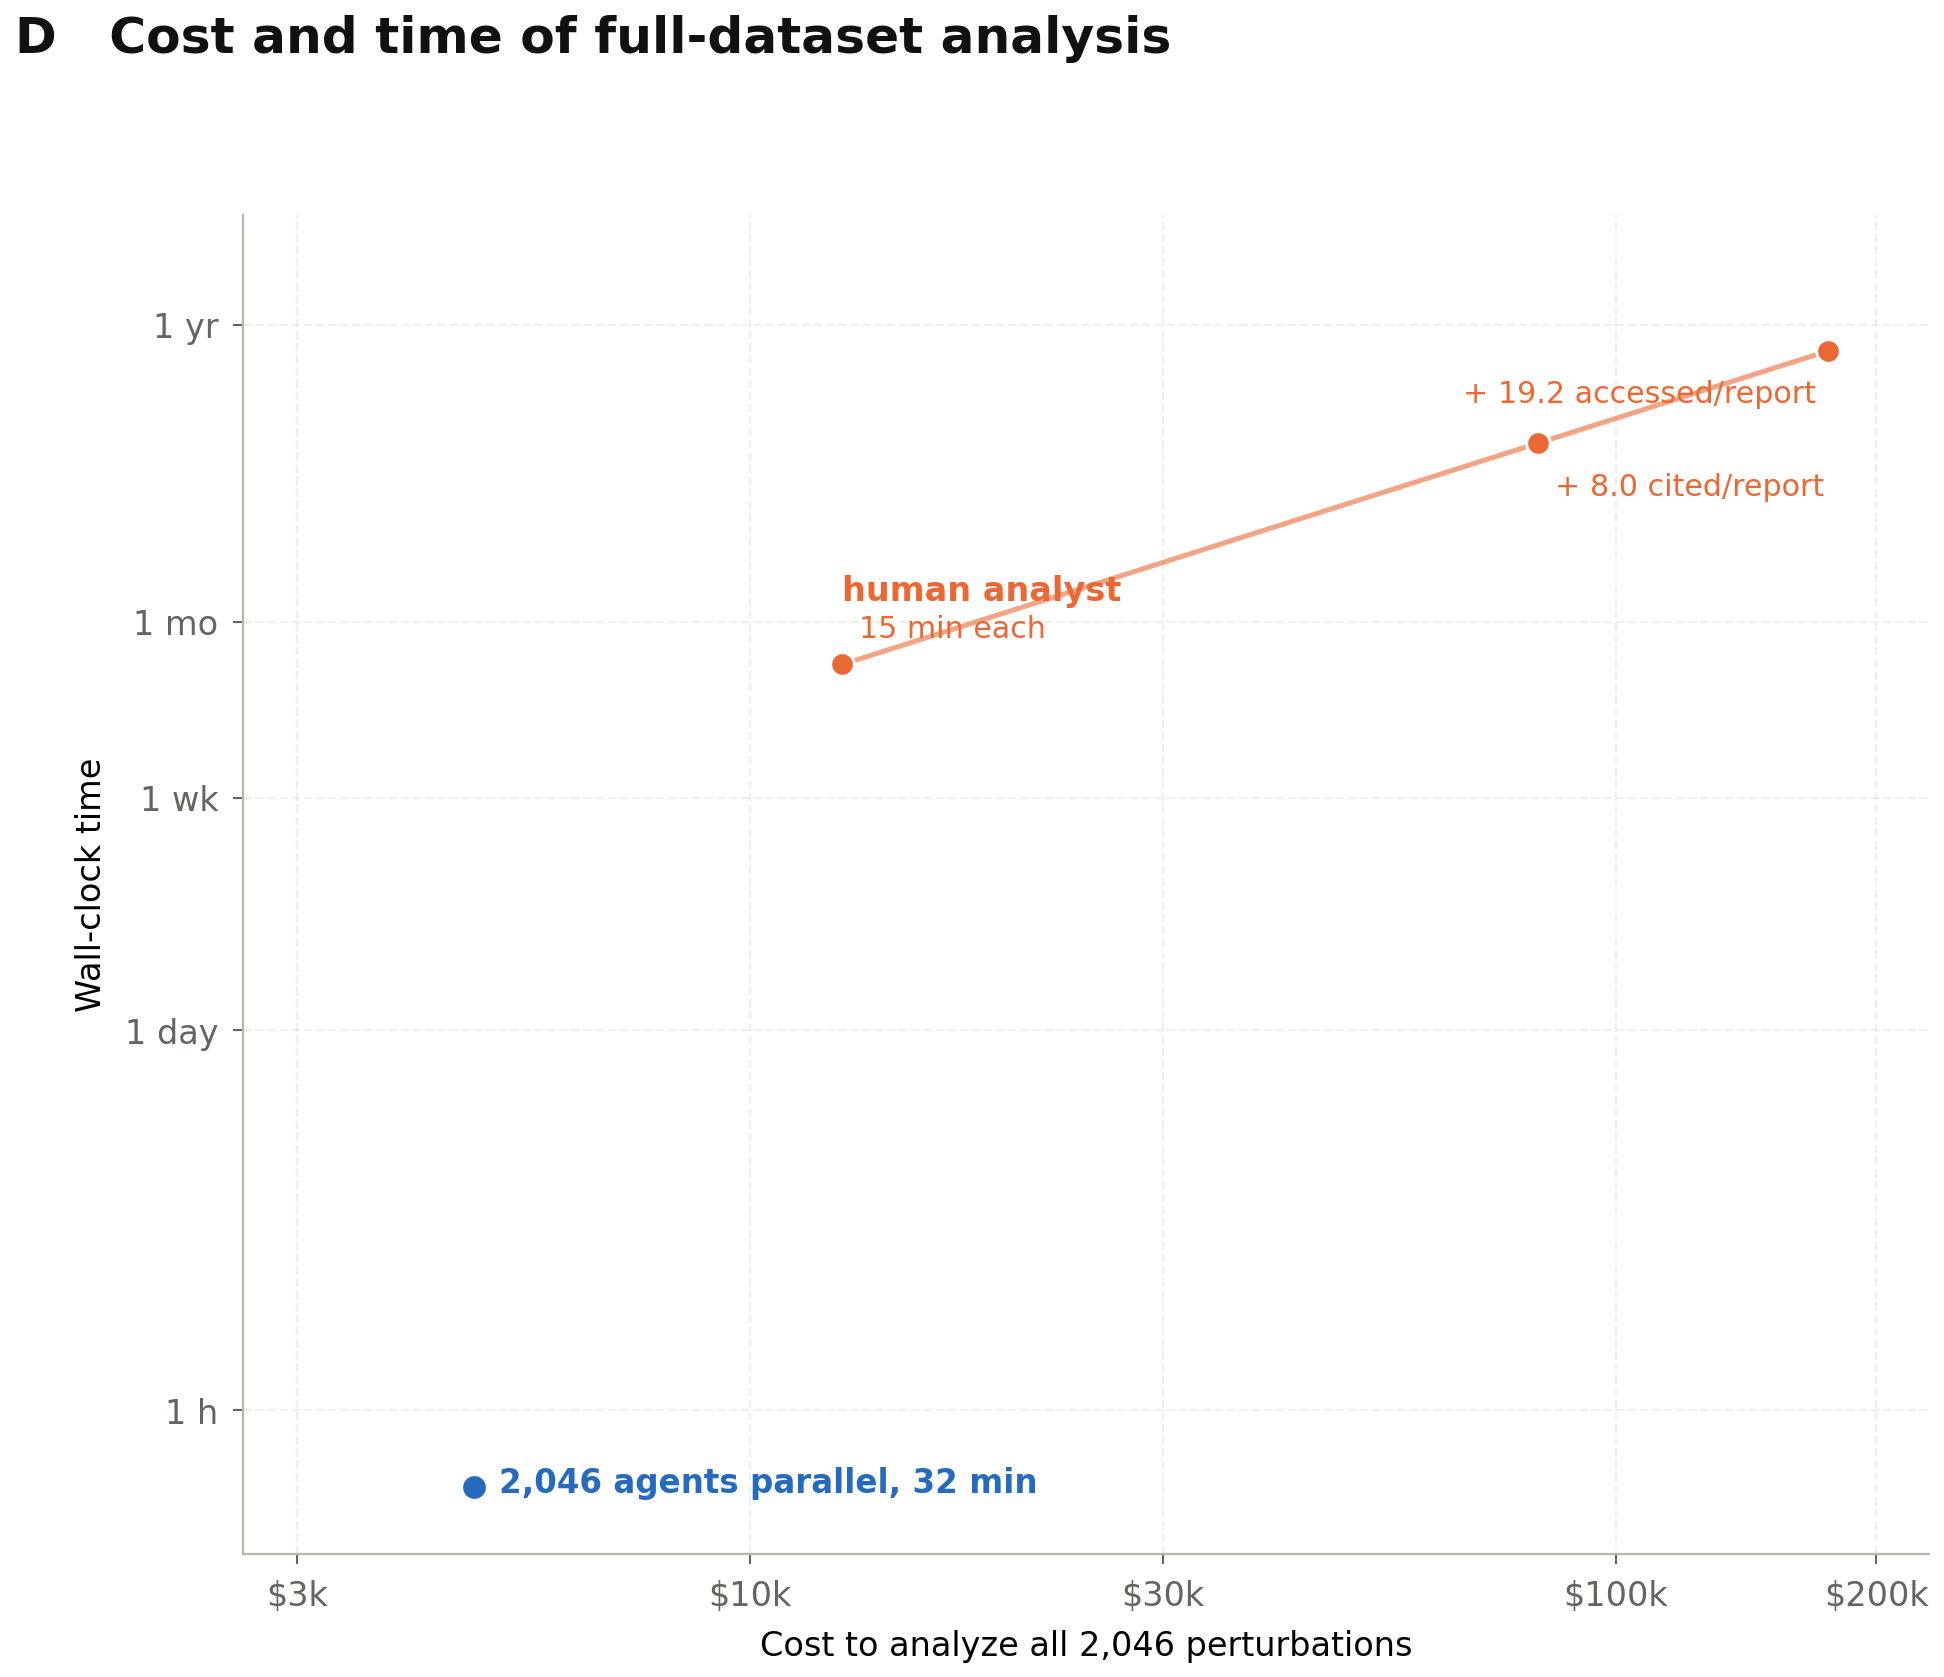

In [6]:
_d_numbers = D_NUMBERS
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading

# ------------------------------------------------------------------ D
def draw_d(container):
    _heading(container, "D", "Cost and time of full-dataset analysis")
    ax = container.subplots()
    analyst_hours = np.array(
        [
            _d_numbers["analyst_base_hours"],
            _d_numbers["analyst_cited_hours"],
            _d_numbers["analyst_accessed_hours"],
        ]
    )
    analyst_cost_k = np.array(
        [
            _d_numbers["analyst_base_cost"],
            _d_numbers["analyst_cited_cost"],
            _d_numbers["analyst_accessed_cost"],
        ]
    ) / 1000
    ax.plot(analyst_cost_k, analyst_hours, color=_CHROME["human"], lw=1.2, alpha=0.6)
    ax.scatter(
        analyst_cost_k,
        analyst_hours,
        s=32,
        color=_CHROME["human"],
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )
    analyst_labels = (
        "15 min each",
        f"+ {_d_numbers['cited_mean']:.1f} cited/report",
        f"+ {_d_numbers['accessed_mean']:.1f} accessed/report",
    )
    for index, (x_value, y_value, label) in enumerate(
        zip(analyst_cost_k, analyst_hours, analyst_labels)
    ):
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(-3 if index == 2 else 4, 5 if index == 0 else -7),
            textcoords="offset points",
            ha="right" if index == 2 else "left",
            va="bottom" if index == 0 else "top",
            fontsize=6.3,
            color=_CHROME["human"],
        )
    ax.text(
        analyst_cost_k[0],
        analyst_hours[0] * 1.7,
        "human analyst",
        fontsize=7.0,
        fontweight="bold",
        color=_CHROME["human"],
    )
    agent_x = _d_numbers["agent_total_cost"] / 1000
    agent_y = _d_numbers["agent_parallel_hours"]
    ax.scatter(
        [agent_x],
        [agent_y],
        s=38,
        color=_CHROME["accessed"],
        edgecolor="white",
        linewidth=0.7,
        zorder=4,
    )
    ax.annotate(
        f"{_d_numbers['n']:,} agents parallel, "
        f"{_d_numbers['agent_unit_min']:.0f} min",
        (agent_x, agent_y),
        xytext=(6, 1),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=6.8,
        fontweight="bold",
        color=_CHROME["accessed"],
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(2.6, 230)
    ax.set_ylim(0.3, 2.2e4)
    ax.set_xticks([3, 10, 30, 100, 200], ["$3k", "$10k", "$30k", "$100k", "$200k"])
    ax.set_yticks(
        [1, 24, 168, 730, 8766],
        ["1 h", "1 day", "1 wk", "1 mo", "1 yr"],
    )
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.set_xlabel(f"Cost to analyze all {_d_numbers['n']:,} perturbations")
    ax.set_ylabel("Wall-clock time")
    _clean_axis(ax, "both")

fig_d, outputs_d = save_panel("D", draw_d, (5.0, 4.0))
fig_d;

## Figure 2E

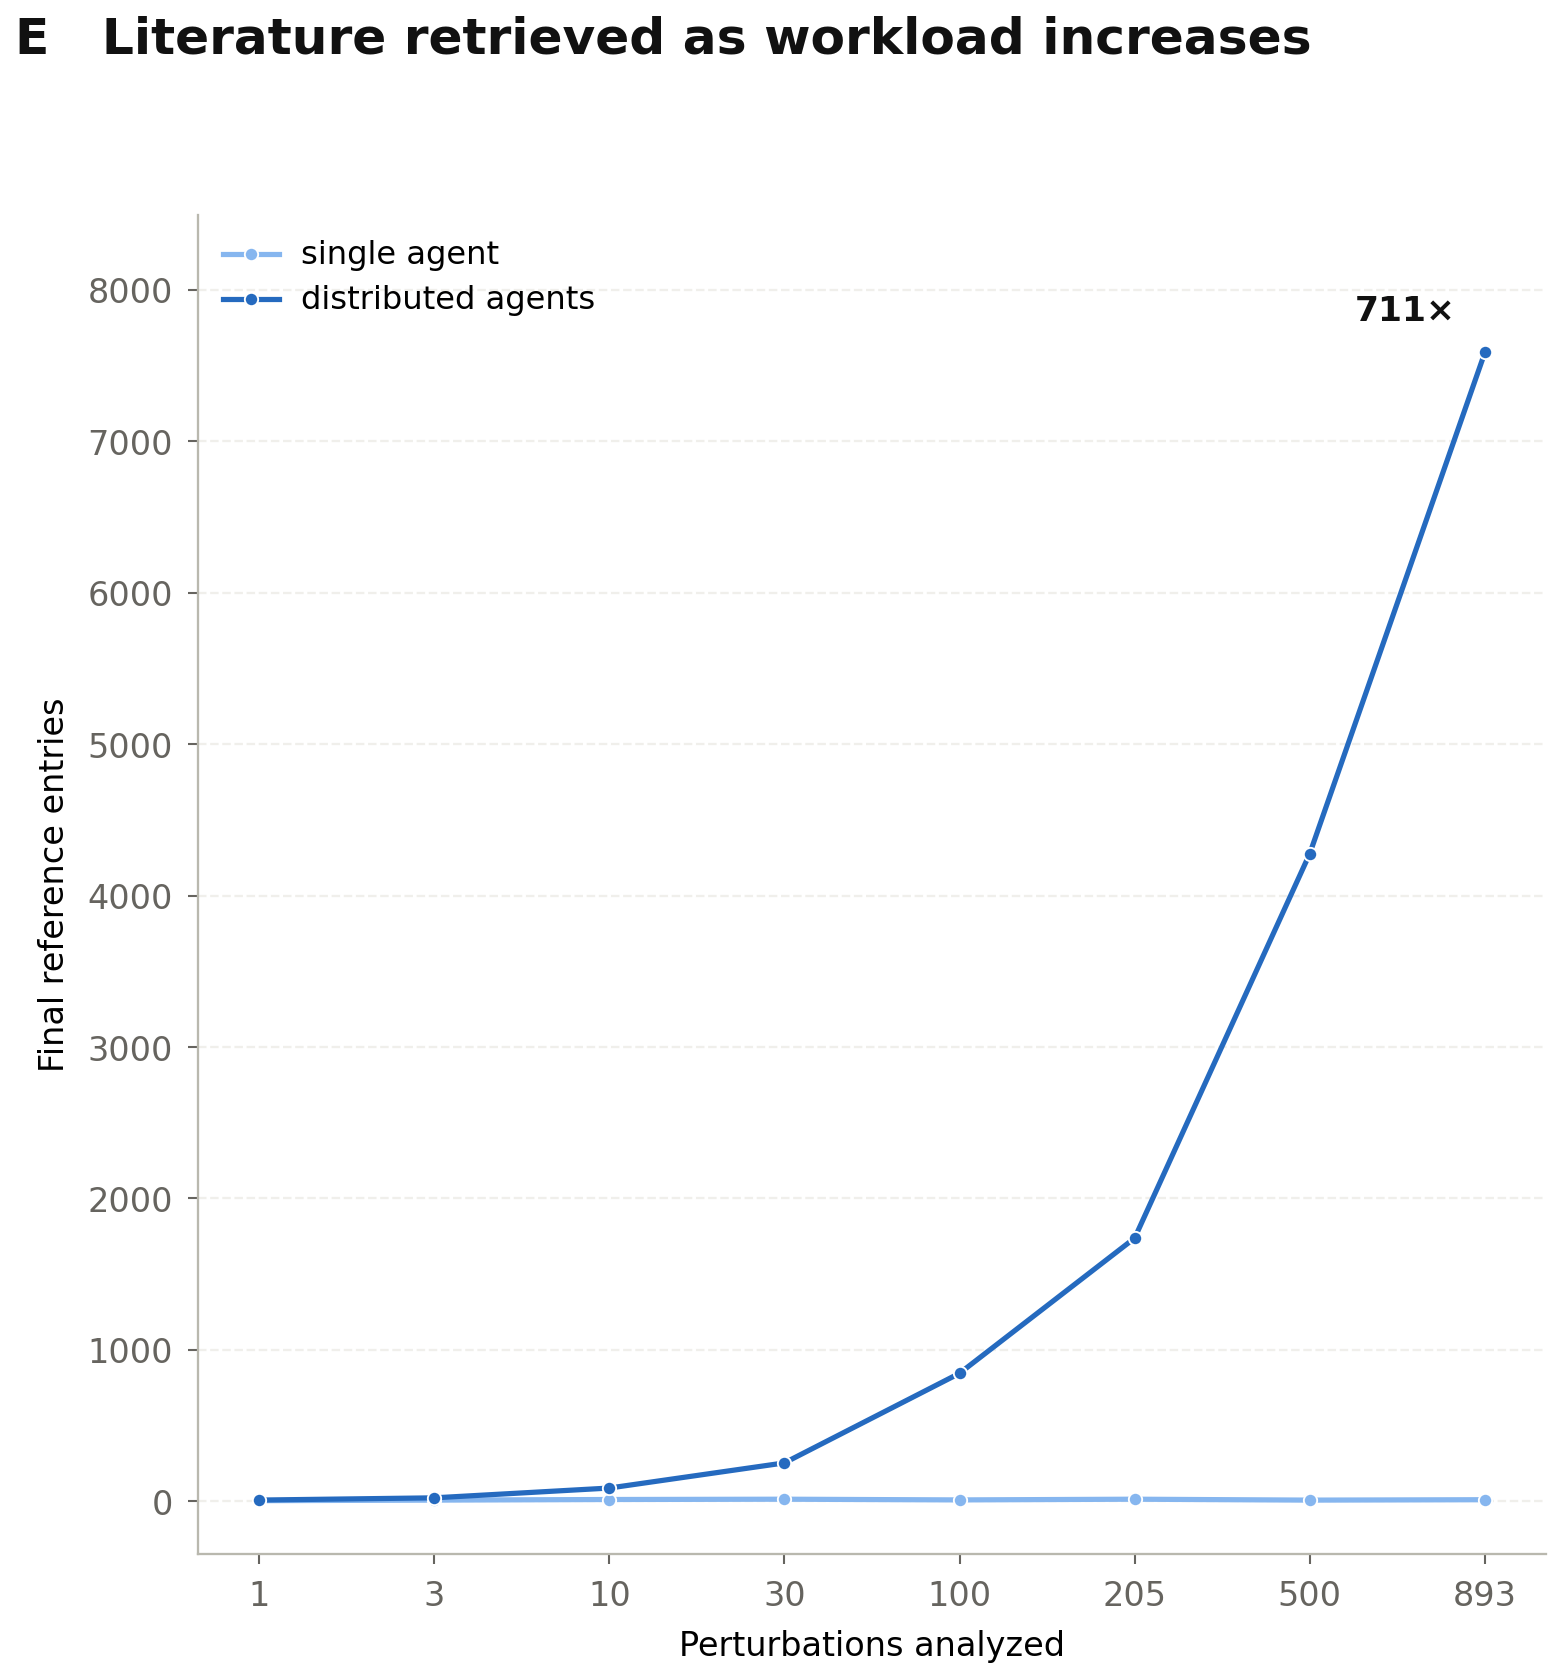

In [7]:
_ARCH_COLORS = ARCH_COLORS
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_scaling = SCALING

# ------------------------------------------------------------------ E
def draw_e(container):
    _heading(container, "E", "Literature retrieved as workload increases")
    ax = container.subplots()
    scales = sorted(_scaling["scale"].astype(int).unique())
    positions = np.arange(len(scales))
    for arm, label in (("single", "single agent"), ("multi", "distributed agents")):
        selected = _scaling[_scaling["arm"] == arm]
        grouped = selected.groupby("scale")["references"]
        means = grouped.mean().reindex(scales)
        sems = grouped.sem().fillna(0).reindex(scales)
        ax.fill_between(
            positions,
            (means - sems).to_numpy(),
            (means + sems).to_numpy(),
            color=_ARCH_COLORS[arm],
            alpha=0.13,
            linewidth=0,
        )
        ax.plot(
            positions,
            means,
            color=_ARCH_COLORS[arm],
            marker="o",
            markersize=3.2,
            markeredgecolor="white",
            markeredgewidth=0.45,
            linewidth=1.25,
            label=label,
        )
    endpoints = (
        _scaling[_scaling["scale"] == scales[-1]]
        .groupby("arm")["references"]
        .mean()
    )
    ratio = endpoints["multi"] / endpoints["single"]
    ax.annotate(
        f"{ratio:.0f}×",
        (positions[-1], endpoints["multi"]),
        xytext=(-7, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=7.2,
        fontweight="bold",
        color=_CHROME["ink"],
    )
    ax.set_xticks(positions, [str(value) for value in scales])
    ax.set_xlim(-0.35, len(scales) - 0.65)
    # The small negative floor lifts the low, flat single-agent series off
    # the baseline without changing its values.
    ax.set_ylim(-350, endpoints["multi"] * 1.12)
    ax.set_xlabel("Perturbations analyzed")
    ax.set_ylabel("Final reference entries")
    ax.legend(loc="upper left", frameon=False, fontsize=6.7)
    _clean_axis(ax, "y")

fig_e, outputs_e = save_panel("E", draw_e, (4.0, 4.0))
fig_e;

## Figure 2F

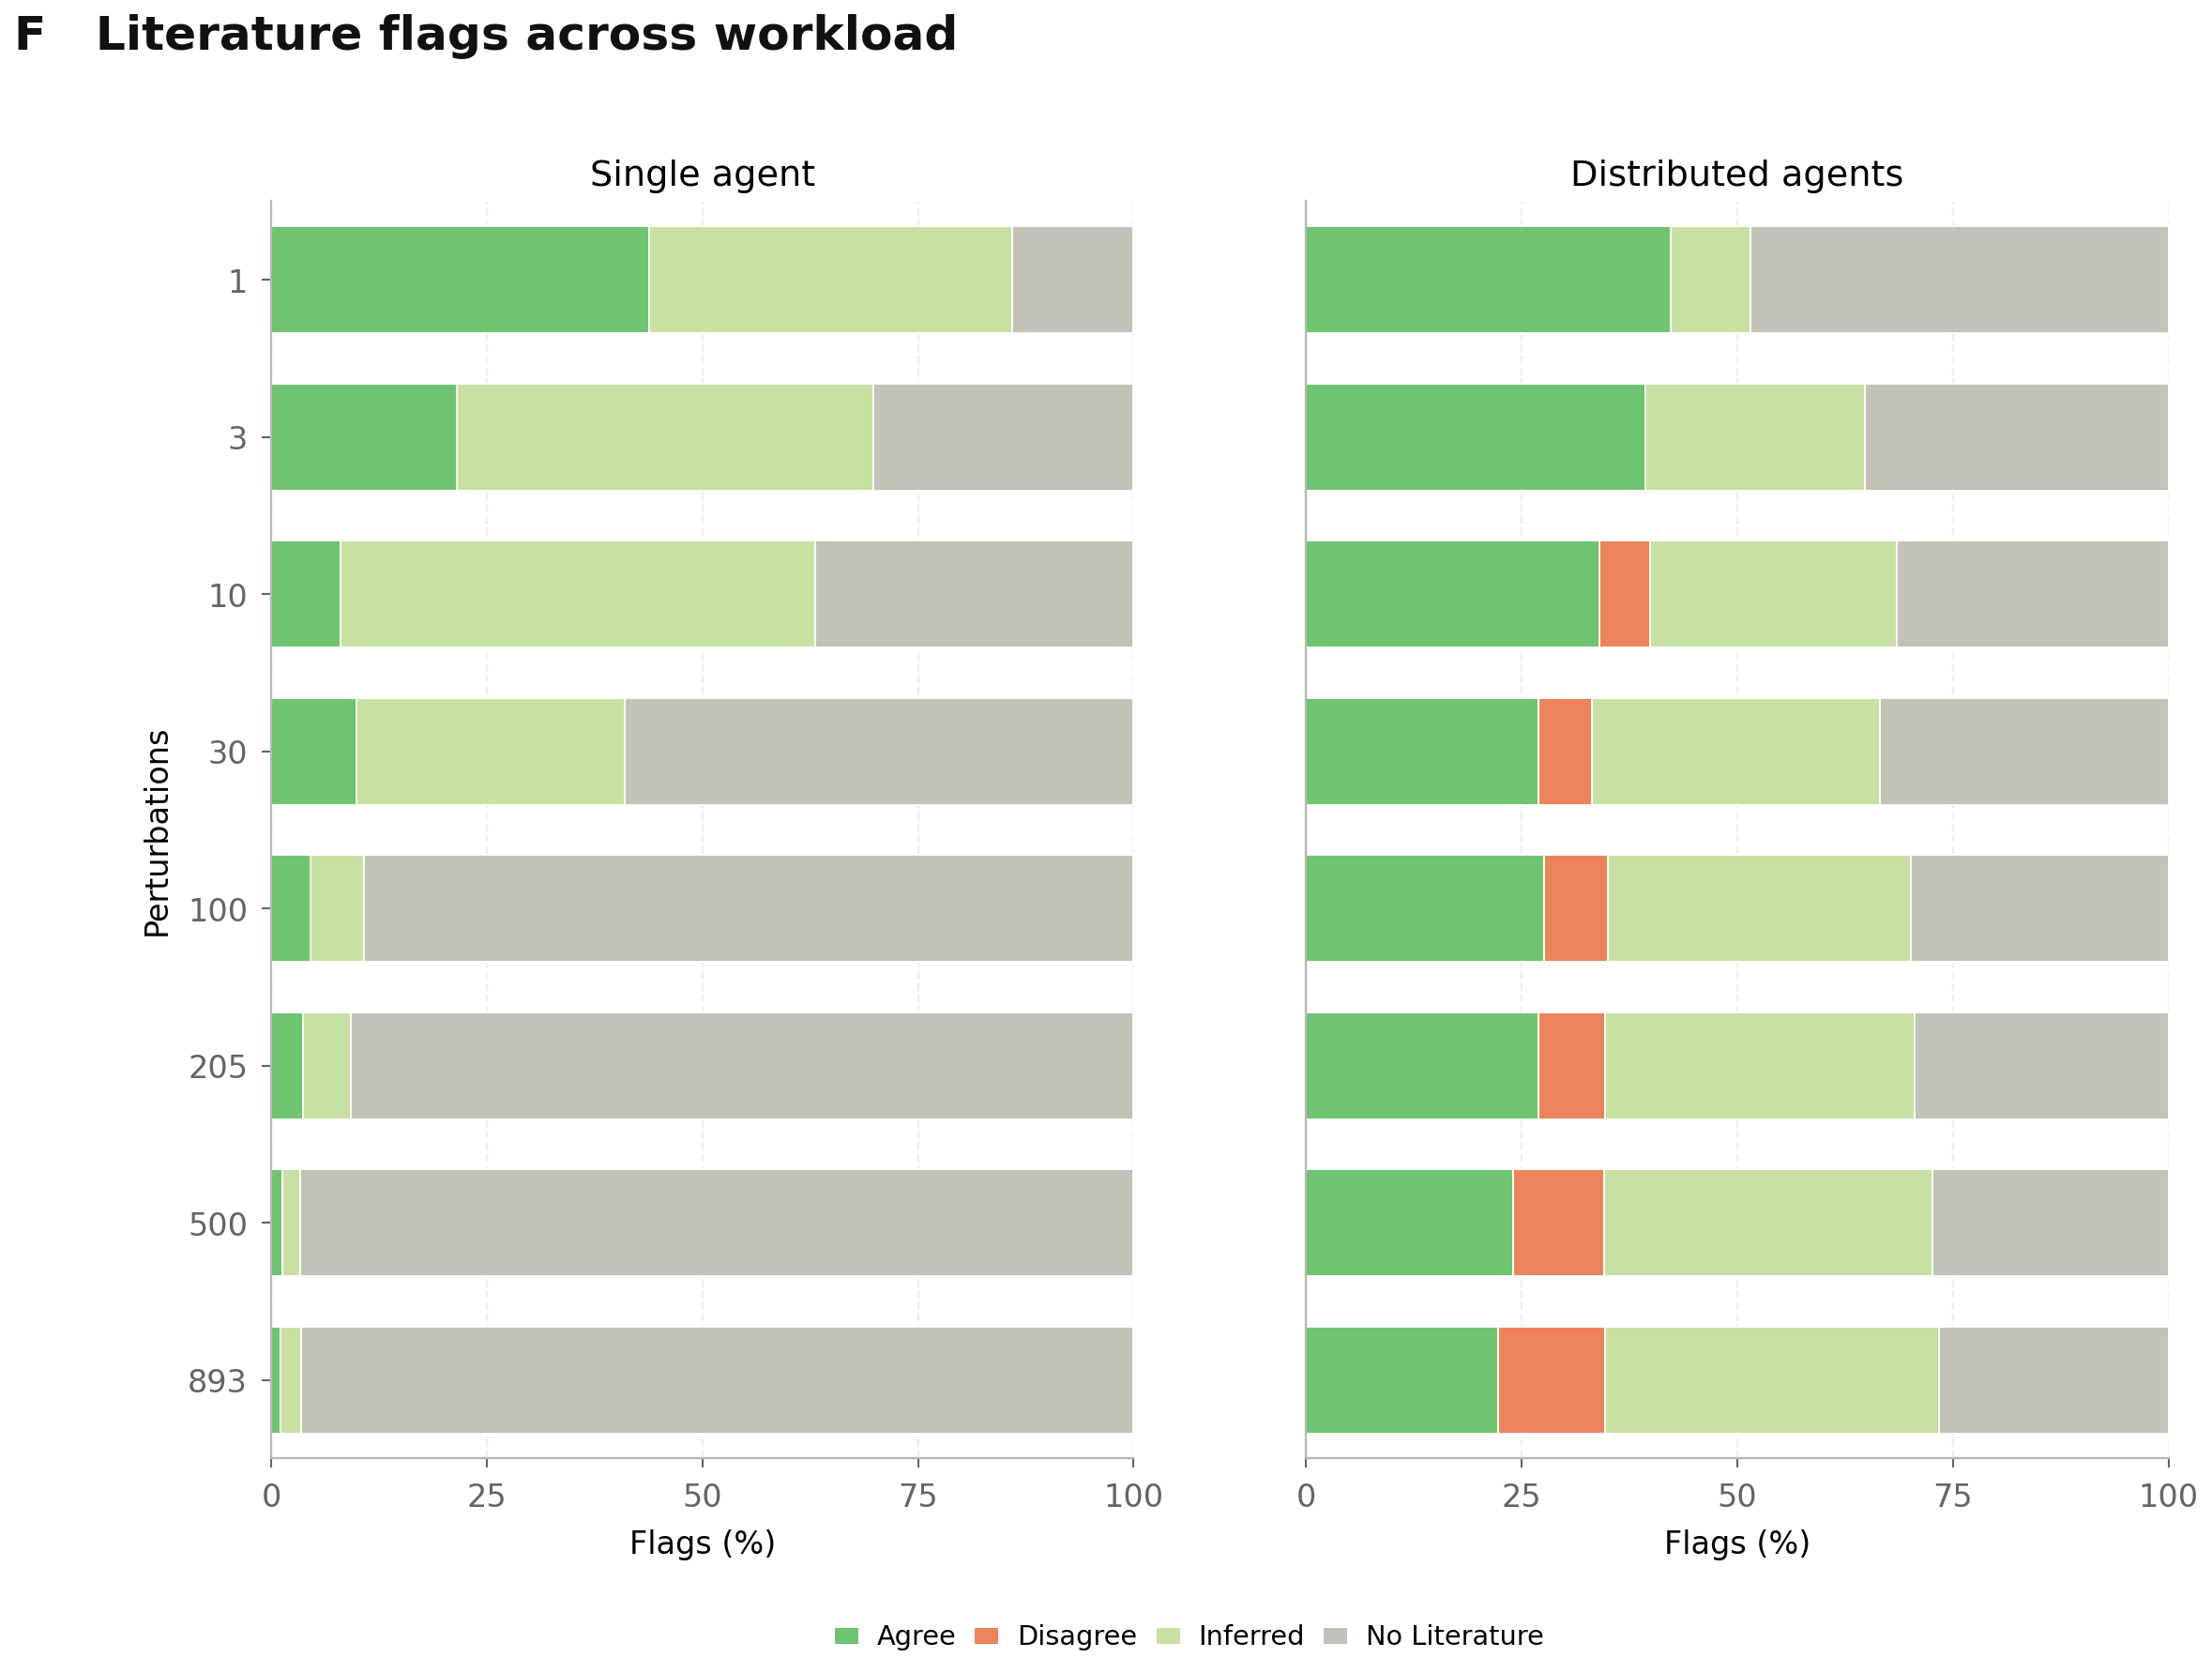

In [8]:
_CHROME = CHROME
_clean_axis = clean_axis
_flag_handles = flag_handles
_heading = heading
_scaling = SCALING

# ------------------------------------------------------------------ F
def draw_f(container):
    _heading(container, "F", "Literature flags across workload")
    axes = container.subplots(1, 2, sharex=True, sharey=True)
    scales = sorted(_scaling["scale"].astype(int).unique())
    for ax, arm, title in zip(
        axes,
        ("single", "multi"),
        ("Single agent", "Distributed agents"),
    ):
        pooled = (
            _scaling[_scaling["arm"] == arm]
            .groupby("scale")[list(FLAG_ORDER)]
            .sum()
            .reindex(scales)
        )
        percentages = pooled.div(pooled.sum(axis=1), axis=0) * 100
        y = np.arange(len(scales))
        left = np.zeros(len(scales))
        for key in FLAG_ORDER:
            width = percentages[key].to_numpy()
            ax.barh(
                y,
                width,
                left=left,
                height=0.68,
                color=FLAG_COLORS[key],
                edgecolor="white",
                linewidth=0.45,
            )
            left += width
        ax.set_title(title, fontsize=8.0, pad=4)
        ax.set_yticks(y, [str(value) for value in scales])
        ax.set_xlim(0, 100)
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_xlabel("Flags (%)")
        _clean_axis(ax, "x")
    axes[0].set_ylabel("Perturbations")
    axes[0].set_ylim(len(scales) - 0.5, -0.5)
    axes[1].tick_params(axis="y", length=0)
    container.legend(
        handles=_flag_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
        fontsize=6.0,
        handlelength=1.0,
        columnspacing=0.8,
    )

fig_f, outputs_f = save_panel("F", draw_f, (6.0, 4.0))
fig_f;

## Figure 2G

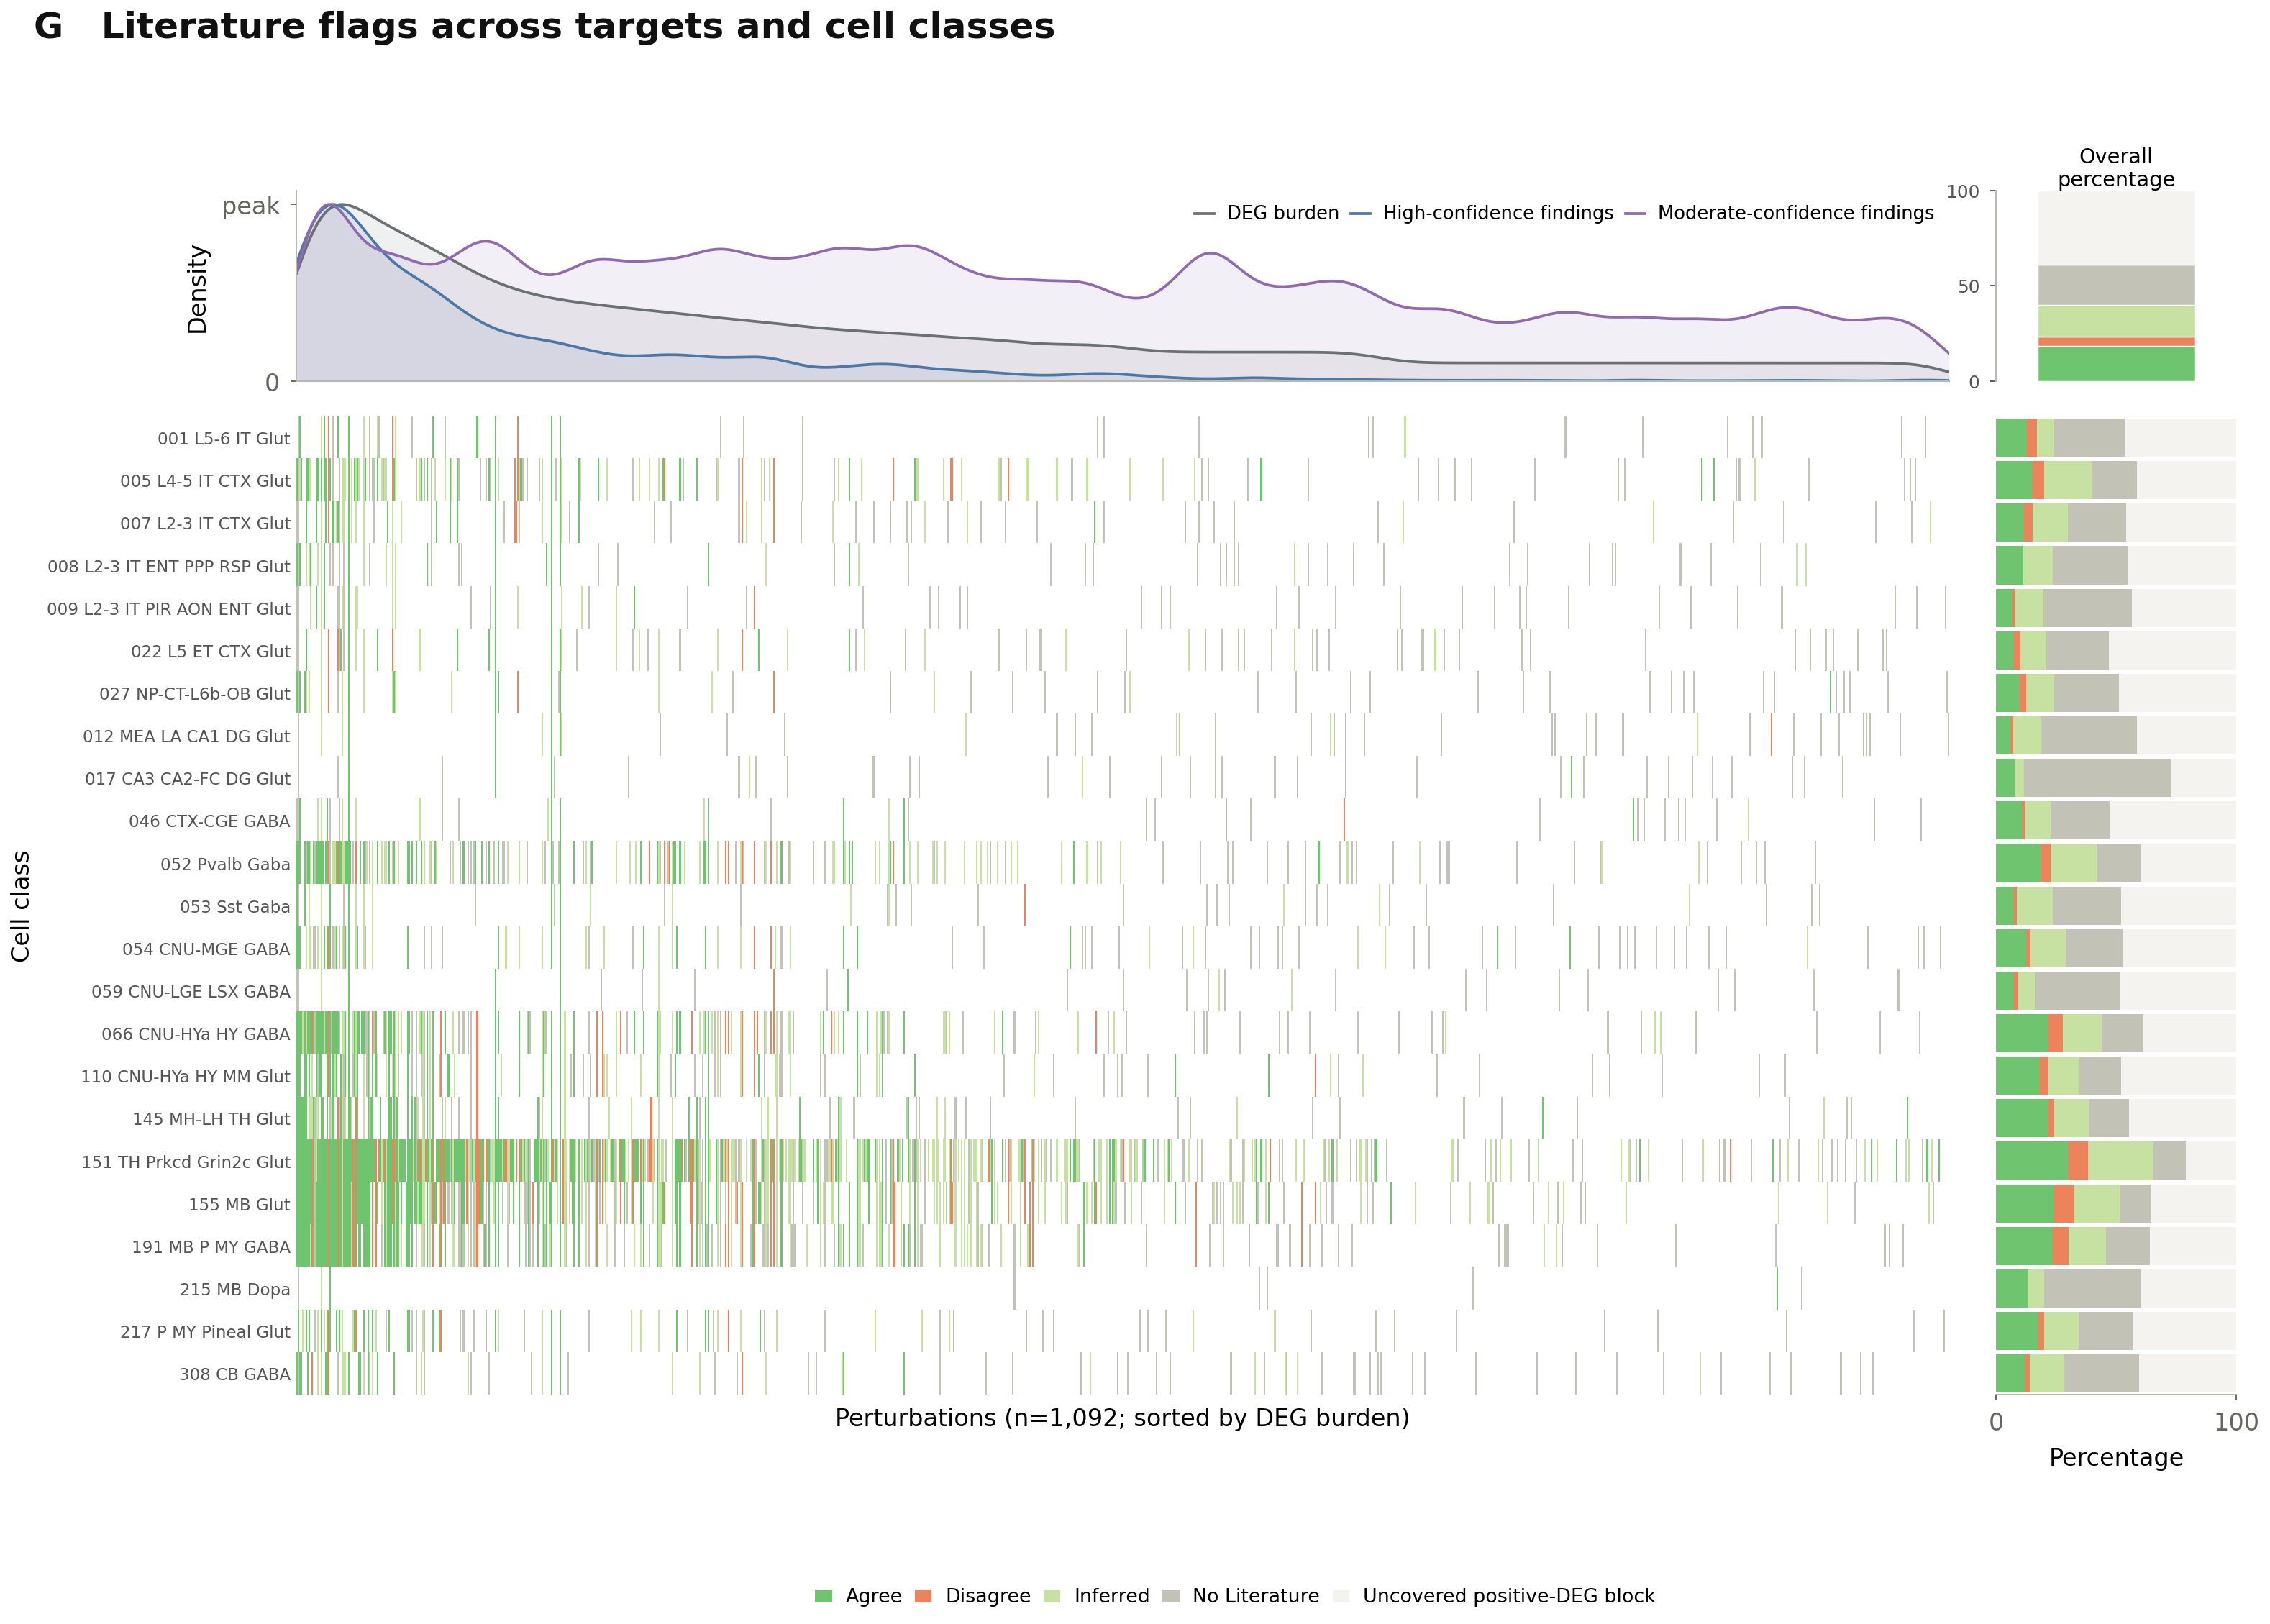

In [9]:
_CHROME = CHROME
_flag_handles = flag_handles
_g_cells = G_CELLS
_heading = heading
_normalize_flag = normalize_flag
_ROOT = repo_root

# ------------------------------------------------------------------ G
def _peak_density(values, bandwidth=18):
    radius = 4 * bandwidth
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / bandwidth) ** 2)
    kernel /= kernel.sum()
    smoothed = np.convolve(np.asarray(values, dtype=float), kernel, mode="same")
    return smoothed / smoothed.max() if smoothed.max() else smoothed

def draw_g(container):
    _heading(container, "G", "Literature flags across targets and cell classes")
    grid = container.add_gridspec(
        2,
        2,
        height_ratios=(1.25, 6.4),
        width_ratios=(8.6, 1.25),
        hspace=0.06,
        wspace=0.05,
    )
    ax_density = container.add_subplot(grid[0, 0])
    ax_overall = container.add_subplot(grid[0, 1])
    ax_matrix = container.add_subplot(grid[1, 0])
    ax_mix = container.add_subplot(grid[1, 1], sharey=ax_matrix)

    targets = list(pd.unique(_g_cells["perturbation"]))
    cell_types = list(pd.unique(_g_cells["cell_type"]))
    displayed = (
        _g_cells.pivot(
            index="cell_type", columns="perturbation", values="displayed_flag"
        )
        .reindex(index=cell_types, columns=targets)
        .map(_normalize_flag)
    )
    code = {"": 0, **{key: index + 1 for index, key in enumerate(FLAG_ORDER)}}
    matrix = displayed.map(code.__getitem__).to_numpy(dtype=float)
    matrix_colors = ["#ffffff", *[FLAG_COLORS[key] for key in FLAG_ORDER]]
    cmap = mcolors.ListedColormap(matrix_colors)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, len(matrix_colors) + 0.5), cmap.N)
    ax_matrix.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        rasterized=True,
    )
    ax_matrix.set_yticks(np.arange(len(cell_types)), cell_types, fontsize=4.8)
    ax_matrix.set_xticks([])
    ax_matrix.set_xlabel(
        f"Perturbations (n={len(targets):,}; sorted by DEG burden)"
    )
    ax_matrix.set_ylabel("Cell class")
    for spine in ax_matrix.spines.values():
        spine.set_visible(False)
    ax_matrix.tick_params(axis="y", length=0, pad=2)

    target_stats = (
        _g_cells.groupby("perturbation", sort=False)
        .agg(
            total_deg=("target_total_deg", "first"),
            high_placements=("n_high_findings", "sum"),
            moderate_placements=("n_moderate_findings", "sum"),
        )
        .reindex(targets)
    )
    # Prefer the reader-view finding counts when they are available.
    # The copied block table is a complete fallback if that
    # repository-level reader view is unavailable.
    findings_path = (
        _ROOT
        / "results"
        / "bioeval"
        / "lit-agree-4flag"
        / "phenotype_findings_by_perturbation_deg_ordered.csv"
    )
    if findings_path.is_file():
        findings = pd.read_csv(
            findings_path,
            usecols=["perturbation", "phenotype_confidence"],
        )
        confidence_counts = (
            findings[
                findings["phenotype_confidence"].isin(["high", "moderate"])
            ]
            .groupby(["perturbation", "phenotype_confidence"])
            .size()
            .unstack(fill_value=0)
            .reindex(targets, fill_value=0)
        )
        high_values = confidence_counts.get("high", pd.Series(0, index=targets))
        moderate_values = confidence_counts.get(
            "moderate", pd.Series(0, index=targets)
        )
    else:
        high_values = target_stats["high_placements"]
        moderate_values = target_stats["moderate_placements"]

    density_series = (
        (
            _peak_density(np.log10(1 + target_stats["total_deg"].to_numpy())),
            "DEG burden",
            _CHROME["deg"],
        ),
        (
            _peak_density(high_values.to_numpy()),
            "High-confidence findings",
            _CHROME["high"],
        ),
        (
            _peak_density(moderate_values.to_numpy()),
            "Moderate-confidence findings",
            _CHROME["moderate"],
        ),
    )
    x = np.arange(len(targets))
    for values, label, color in density_series:
        ax_density.fill_between(x, 0, values, color=color, alpha=0.10, linewidth=0)
        ax_density.plot(x, values, color=color, linewidth=0.9, label=label)
    ax_density.set_xlim(0, len(targets) - 1)
    ax_density.set_ylim(0, 1.08)
    ax_density.set_xticks([])
    ax_density.set_yticks([0, 1], ["0", "peak"])
    ax_density.set_ylabel("Density")
    ax_density.legend(
        loc="upper right",
        frameon=False,
        fontsize=5.4,
        ncol=3,
        handlelength=1.2,
        columnspacing=0.7,
    )
    ax_density.spines[["top", "right"]].set_visible(False)
    ax_density.spines[["left", "bottom"]].set_color(_CHROME["axis"])
    ax_density.tick_params(length=2, width=0.45, colors=_CHROME["muted"])

    positive = _g_cells[_g_cells["in_positive_deg_universe"] == 1].copy()
    positive["mix_key"] = positive["displayed_flag"].map(_normalize_flag)
    positive.loc[positive["mix_key"] == "", "mix_key"] = "uncovered"
    mix_order = (*FLAG_ORDER, "uncovered")
    mix_colors = {**FLAG_COLORS, "uncovered": _CHROME["uncovered"]}
    y = np.arange(len(cell_types))
    left = np.zeros(len(cell_types))
    for key in mix_order:
        fractions = []
        for cell_type in cell_types:
            values = positive.loc[positive["cell_type"] == cell_type, "mix_key"]
            fractions.append(100 * float((values == key).sum()) / len(values))
        ax_mix.barh(
            y,
            fractions,
            left=left,
            height=0.90,
            color=mix_colors[key],
            edgecolor="none",
        )
        left += np.asarray(fractions)
    ax_mix.set_xlim(0, 100)
    ax_mix.set_xticks([0, 100])
    ax_mix.set_xlabel("Percentage")
    ax_mix.tick_params(axis="y", left=False, labelleft=False)
    ax_mix.spines[["top", "right", "left"]].set_visible(False)
    ax_mix.spines["bottom"].set_color(_CHROME["axis"])
    ax_mix.tick_params(axis="x", length=2, width=0.45, colors=_CHROME["muted"])

    overall_counts = positive["mix_key"].value_counts()
    overall_total = len(positive)
    bottom = 0.0
    for key in mix_order:
        height = 100 * float(overall_counts.get(key, 0)) / overall_total
        ax_overall.bar(
            0,
            height,
            bottom=bottom,
            width=0.72,
            color=mix_colors[key],
            edgecolor="white",
            linewidth=0.35,
        )
        bottom += height
    ax_overall.set_xlim(-0.55, 0.55)
    ax_overall.set_ylim(0, 100)
    ax_overall.set_xticks([])
    ax_overall.set_yticks([0, 50, 100], ["0", "50", "100"])
    ax_overall.set_title("Overall\npercentage", fontsize=6.0, pad=1)
    ax_overall.spines[["top", "right", "bottom"]].set_visible(False)
    ax_overall.spines["left"].set_color(_CHROME["axis"])
    ax_overall.tick_params(axis="y", length=2, width=0.45, labelsize=5.2)

    container.legend(
        handles=_flag_handles()
        + [
            Patch(
                facecolor=_CHROME["uncovered"],
                edgecolor="none",
                label="Uncovered positive-DEG block",
            )
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.035),
        ncol=5,
        frameon=False,
        fontsize=5.6,
        handlelength=1.0,
        columnspacing=0.75,
    )

fig_g, outputs_g = save_panel("G", draw_g, (8.0, 5.0))
fig_g;

## Figure 2H

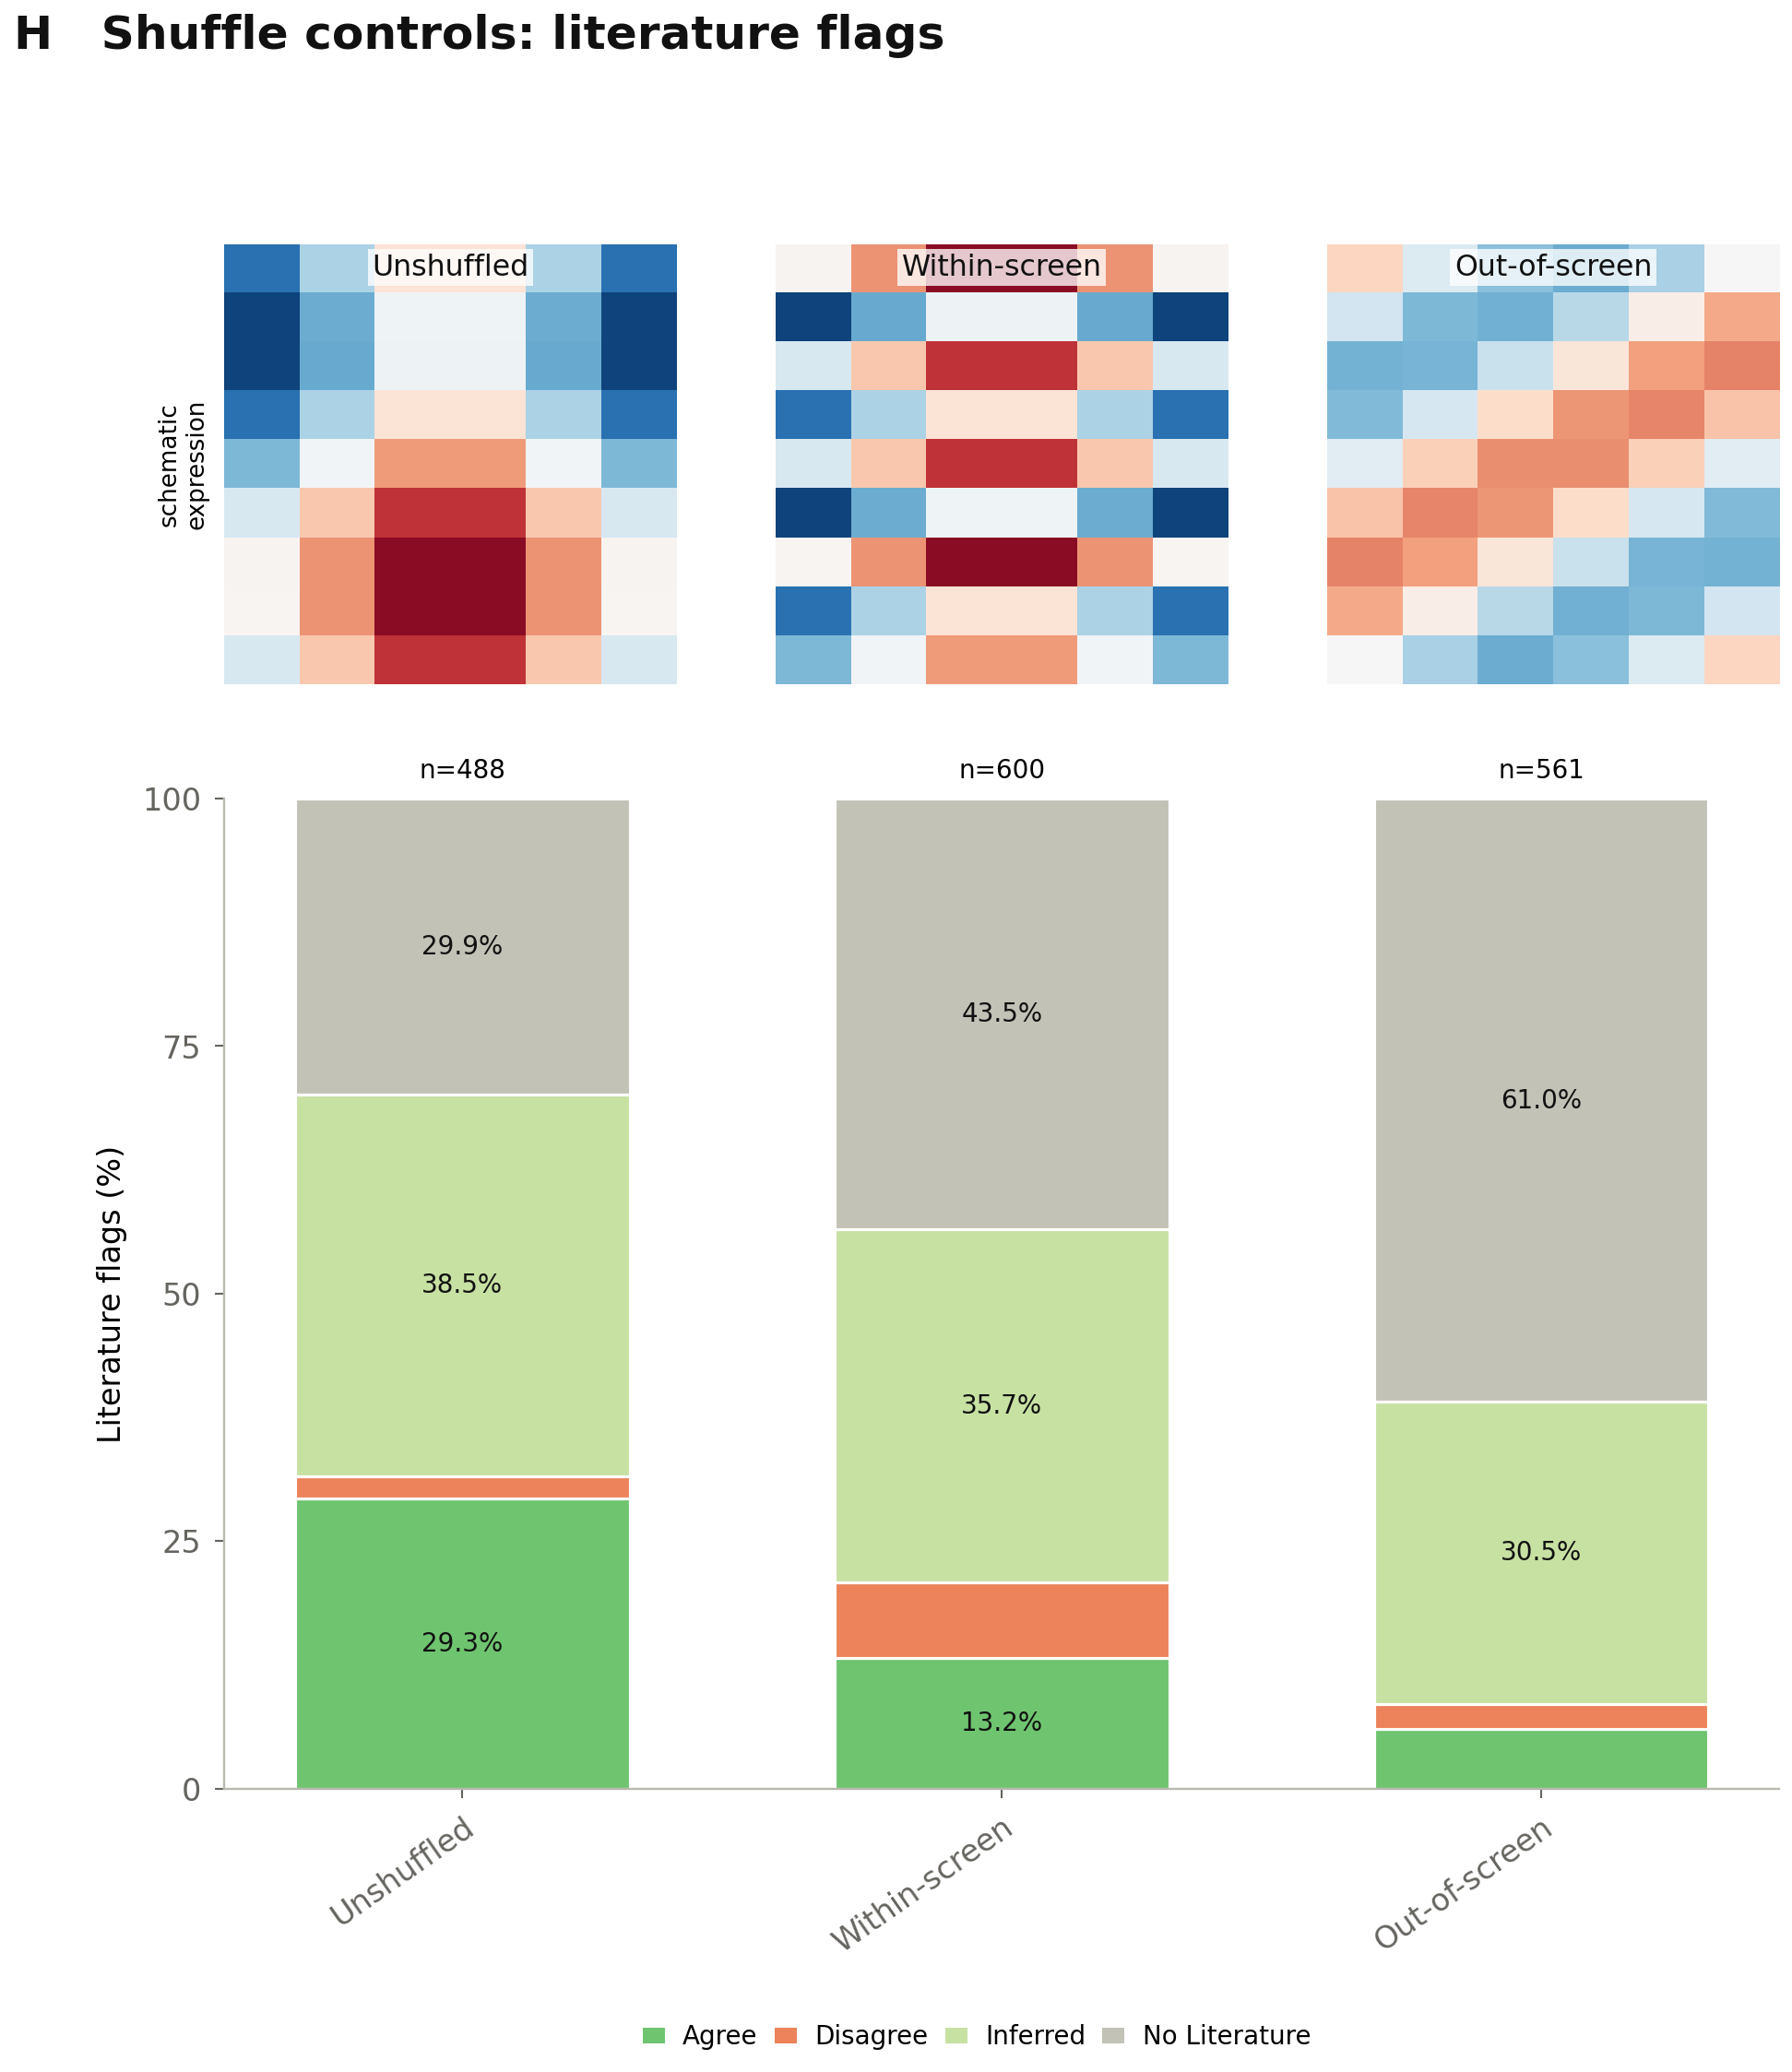

In [10]:
_CHROME = CHROME
_clean_axis = clean_axis
_flag_handles = flag_handles
_h = H_DATA
_heading = heading

# ------------------------------------------------------------------ H
def draw_h(container):
    _heading(container, "H", "Shuffle controls: literature flags")
    grid = container.add_gridspec(2, 3, height_ratios=(1.0, 2.25), hspace=0.16, wspace=0.22)
    short_arms = ("Unshuffled", "Within-screen", "Out-of-screen")
    x = np.linspace(-1.5, 1.5, 6)
    y = np.linspace(-1.2, 1.2, 9)
    base = np.sin(y[:, None] * 2.1) + np.cos(x[None, :] * 1.8)
    within = base[[6, 2, 8, 0, 5, 1, 7, 3, 4], :]
    out = np.cos(y[:, None] * 2.8 + x[None, :] * 1.2)
    for index, (values, title) in enumerate(zip((base, within, out), short_arms)):
        ax_heat = container.add_subplot(grid[0, index])
        ax_heat.imshow(
            values,
            aspect="auto",
            interpolation="nearest",
            cmap="RdBu_r",
            vmin=-2,
            vmax=2,
            rasterized=True,
        )
        ax_heat.text(
            0.5,
            0.98,
            title,
            transform=ax_heat.transAxes,
            ha="center",
            va="top",
            fontsize=6.6,
            color=_CHROME["ink"],
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.0},
        )
        ax_heat.set_xticks([])
        ax_heat.set_yticks([])
        for spine in ax_heat.spines.values():
            spine.set_visible(False)
        if index == 0:
            ax_heat.set_ylabel("schematic\nexpression", fontsize=5.5)

    ax = container.add_subplot(grid[1, :])
    data = _h[_h["analysis_layer"] == "primary"].copy()
    arms = list(pd.unique(data["arm"]))
    x_positions = np.arange(len(arms))
    bottoms = np.zeros(len(arms))
    for key in FLAG_ORDER:
        selected = data[data["flag"] == key].set_index("arm").reindex(arms)
        heights = selected["percent"].to_numpy(dtype=float)
        ax.bar(
            x_positions,
            heights,
            bottom=bottoms,
            width=0.62,
            color=FLAG_COLORS[key],
            edgecolor="white",
            linewidth=0.75,
        )
        for xx, yy, height in zip(x_positions, bottoms, heights):
            if height >= 9:
                ax.text(
                    xx,
                    yy + height / 2,
                    f"{height:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color=_CHROME["ink"],
                )
        bottoms += heights
    for xx, arm in zip(x_positions, arms):
        n_findings = int(data[data["arm"] == arm]["n_findings"].iloc[0])
        ax.text(xx, 101.5, f"n={n_findings:,}", ha="center", va="bottom", fontsize=5.8)
    ax.set_xticks(x_positions, short_arms, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylabel("Literature flags (%)")
    _clean_axis(ax, None)
    container.legend(
        handles=_flag_handles(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=4,
        frameon=False,
        fontsize=5.8,
        handlelength=1.0,
        columnspacing=0.75,
    )

fig_h, outputs_h = save_panel("H", draw_h, (5.0, 5.0))
fig_h;

## Figure 2I

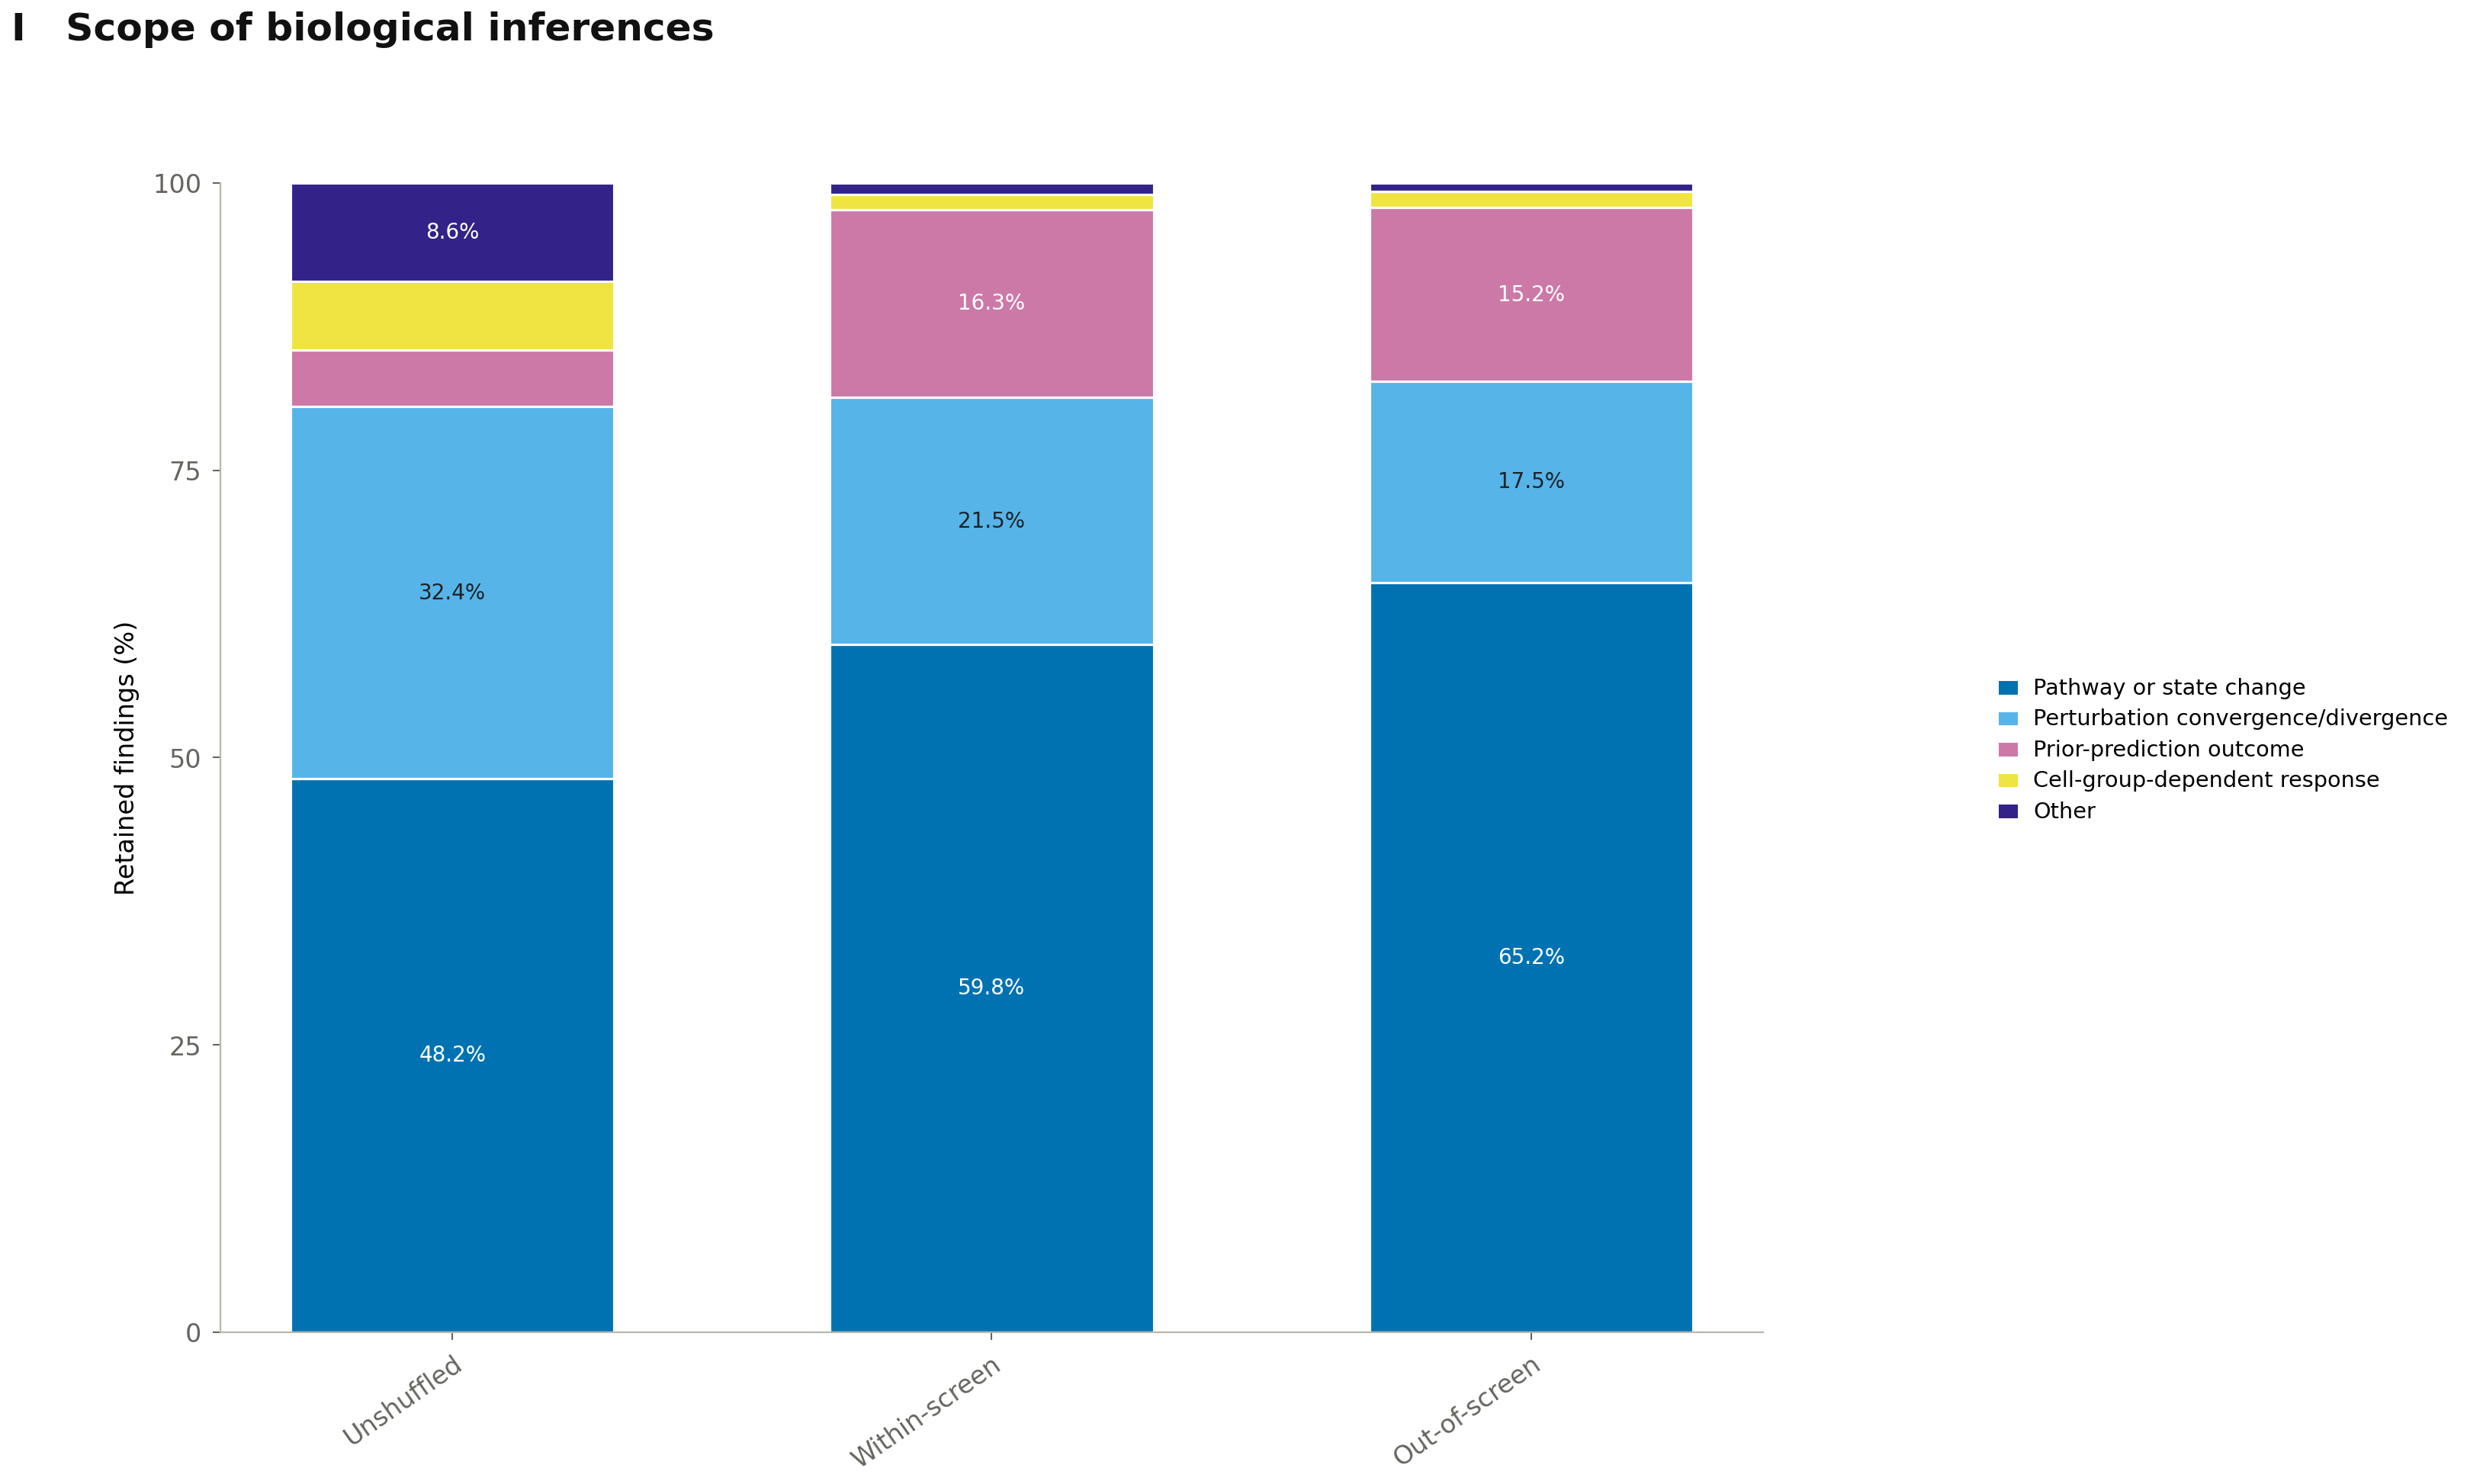

In [11]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_i = I_DATA
_SCOPE_COLORS = SCOPE_COLORS
_SCOPE_LABELS = SCOPE_LABELS
_SCOPE_ORDER = SCOPE_ORDER

# ------------------------------------------------------------------ I
def draw_i(container):
    _heading(container, "I", "Scope of biological inferences")
    ax = container.subplots()
    data = _i[_i["analysis_layer"] == "primary"].copy()
    arms = list(pd.unique(data["arm"]))
    short_arms = ("Unshuffled", "Within-screen", "Out-of-screen")
    x_positions = np.arange(len(arms))
    bottoms = np.zeros(len(arms))
    for scope in _SCOPE_ORDER:
        selected = data[data["scope"] == scope].set_index("arm").reindex(arms)
        heights = selected["percent"].to_numpy(dtype=float)
        ax.bar(
            x_positions,
            heights,
            bottom=bottoms,
            width=0.60,
            color=_SCOPE_COLORS[scope],
            edgecolor="white",
            linewidth=0.75,
        )
        for xx, yy, height in zip(x_positions, bottoms, heights):
            if height >= 8:
                text_color = "#1f2326" if scope in {"comparator_relationship", "cell_group_relationship"} else "white"
                ax.text(
                    xx,
                    yy + height / 2,
                    f"{height:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color=text_color,
                )
        bottoms += heights
    ax.set_xticks(x_positions, short_arms, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylabel("Retained findings (%)")
    _clean_axis(ax, None)
    handles = [
        Patch(facecolor=_SCOPE_COLORS[key], edgecolor="none", label=_SCOPE_LABELS[key])
        for key in _SCOPE_ORDER
    ]
    container.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.50),
        frameon=False,
        fontsize=6.0,
        handlelength=1.0,
    )

fig_i, outputs_i = save_panel("I", draw_i, (6.0, 4.5))
fig_i;

## Figure 2J — Tsc1/Tsc2 shared neuronal state

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


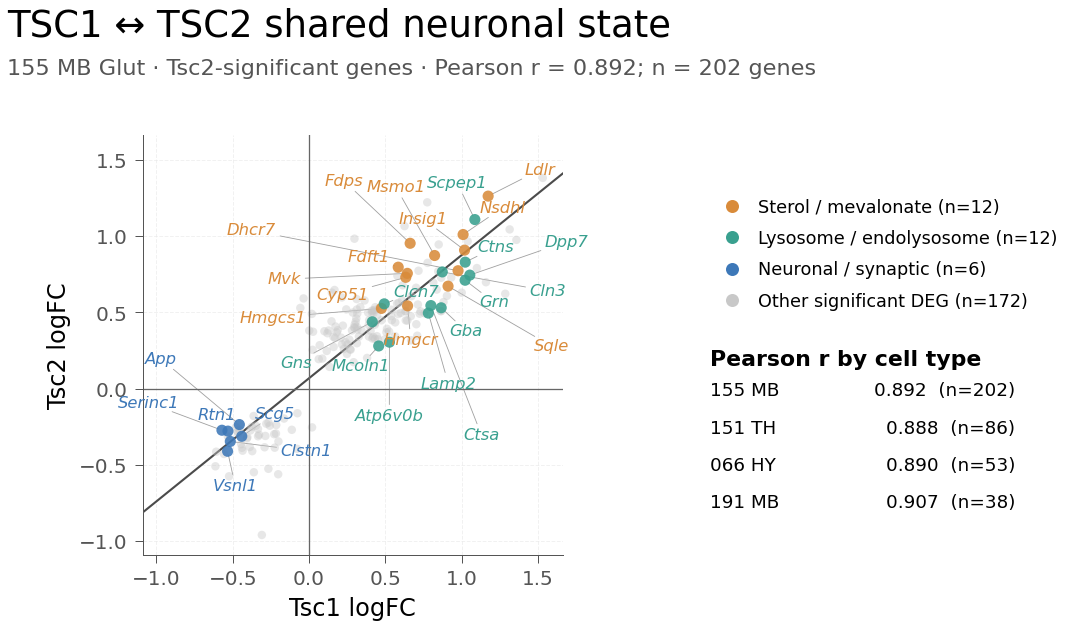

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.stats import pearsonr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text
OUT = ROOT / 'src/manuscript_figures/fig2/j'
DEG = DEG_PATH
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})
groups = ['155 MB Glut', '151 TH Prkcd Grin2c Glut', '066 CNU-HYa HY GABA', '191 MB P MY GABA']
short = ['155 MB', '151 TH', '066 HY', '191 MB']
modules = {'Sterol / mevalonate': ['Insig1', 'Ldlr', 'Hmgcs1', 'Sqle', 'Cyp51', 'Msmo1', 'Dhcr7', 'Fdft1', 'Fdps', 'Nsdhl', 'Hmgcr', 'Mvk', 'Mvd'], 'Lysosome / endolysosome': ['Atp6v0b', 'Lamp2', 'Mcoln1', 'Clcn7', 'Gba', 'Neu1', 'Grn', 'Ctsa', 'Gns', 'Ctns', 'Cln3', 'Scpep1', 'Dpp7'], 'Neuronal / synaptic': ['App', 'Syp', 'Syt1', 'Rtn1', 'Clstn1', 'Serinc1', 'Atp2a2', 'Scg5', 'Vsnl1', 'Gabra1', 'Glrb', 'Lynx1', 'Rab3a']}
colors = {'Sterol / mevalonate': '#D98B3A', 'Lysosome / endolysosome': '#39A08F', 'Neuronal / synaptic': '#3D78B8', 'Other Tsc2-significant DEG': '#C8C8C8'}
raw = pq.read_table(DEG, columns=['names', 'gene_target', 'group_name', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', 'in', groups), ('gene_target', 'in', ['Tsc1', 'Tsc2'])]).to_pandas()
panels = {}
stats = []
for group, label in zip(groups, short):
    x = raw[raw.group_name.eq(group)]
    a = x[x.gene_target.eq('Tsc1')].set_index('names')[['logfoldchanges']].rename(columns={'logfoldchanges': 'Tsc1_logFC'})
    b = x[x.gene_target.eq('Tsc2')].set_index('names')[['logfoldchanges', 'pvals_adj']].rename(columns={'logfoldchanges': 'Tsc2_logFC', 'pvals_adj': 'Tsc2_FDR'})
    d = a.join(b, how='inner')
    d = d[d.Tsc2_FDR < 0.05].copy()
    d['module'] = 'Other Tsc2-significant DEG'
    for module, genes in modules.items():
        d.loc[d.index.isin(genes), 'module'] = module
    r = pearsonr(d.Tsc1_logFC, d.Tsc2_logFC).statistic
    stats.append((label, r, len(d)))
    panels[group] = d
assert [round(x[1], 3) for x in stats] == [0.892, 0.888, 0.89, 0.907]
df = panels['155 MB Glut']
r = stats[0][1]
fig, ax = plt.subplots(figsize=(8.0, 4.7))
fig.subplots_adjust(left=0.11, right=0.67, bottom=0.15, top=0.77)
for module in ['Other Tsc2-significant DEG', 'Sterol / mevalonate', 'Lysosome / endolysosome', 'Neuronal / synaptic']:
    d = df[df.module.eq(module)]
    ax.scatter(d.Tsc1_logFC, d.Tsc2_logFC, s=18 if module.startswith('Other') else 31, c=colors[module], edgecolor='none', alpha=0.42 if module.startswith('Other') else 0.88, zorder=2 if module.startswith('Other') else 3)
lo = min(df.Tsc1_logFC.min(), df.Tsc2_logFC.min()) - 0.13
hi = max(df.Tsc1_logFC.max(), df.Tsc2_logFC.max()) + 0.13
slope, intercept = np.polyfit(df.Tsc1_logFC, df.Tsc2_logFC, 1)
xx = np.array([lo, hi])
ax.plot(xx, slope * xx + intercept, color='#4B4B4B', lw=1.05, zorder=1)
ax.axhline(0, color='#666666', lw=0.65)
ax.axvline(0, color='#666666', lw=0.65)
texts = []
for gene, row in df[~df.module.eq('Other Tsc2-significant DEG')].iterrows():
    texts.append(ax.text(row.Tsc1_logFC, row.Tsc2_logFC, gene, fontsize=8.2, fontstyle='italic', color=colors[row.module], zorder=4))
adjust_text(texts, ax=ax, expand=(1.48, 1.58), force_text=(1.0, 1.2), force_static=(0.4, 0.52), explode_radius=85, max_move=(28, 28), iter_lim=1800, prevent_crossings=True, arrowprops=dict(arrowstyle='-', color='#A0A0A0', lw=0.42))
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Tsc1 logFC', fontsize=12)
ax.set_ylabel('Tsc2 logFC', fontsize=12)
ax.grid(color='#E8E8E8', lw=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)
display = {'Sterol / mevalonate': 'Sterol / mevalonate', 'Lysosome / endolysosome': 'Lysosome / endolysosome', 'Neuronal / synaptic': 'Neuronal / synaptic', 'Other Tsc2-significant DEG': 'Other significant DEG'}
legend = [Line2D([0], [0], marker='o', ls='', color=colors[m], markersize=5.5, label=f'{display[m]} (n={(df.module == m).sum()})') for m in ['Sterol / mevalonate', 'Lysosome / endolysosome', 'Neuronal / synaptic', 'Other Tsc2-significant DEG']]
fig.legend(handles=legend, loc='upper left', bbox_to_anchor=(0.69, 0.7), frameon=False, fontsize=8.8, handletextpad=0.5, labelspacing=0.75)
fig.text(0.7, 0.43, 'Pearson r by cell type', ha='left', fontsize=11, fontweight='bold')
for i, (label, rr, n) in enumerate(stats):
    fig.text(0.7, 0.385 - i * 0.055, label, ha='left', fontsize=9.2)
    fig.text(0.965, 0.385 - i * 0.055, f'{rr:.3f}  (n={n})', ha='right', fontsize=9.2)
fig.suptitle('TSC1 ↔ TSC2 shared neuronal state', x=0.09, y=0.96, ha='left', fontsize=18.5)
fig.text(0.09, 0.86, f'155 MB Glut · Tsc2-significant genes · Pearson r = {r:.3f}; n = {len(df)} genes', ha='left', fontsize=11.2, color='#555555')
plt.show()

## Figure 2K — Rab7/Tsc lysosome–sterol programs

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


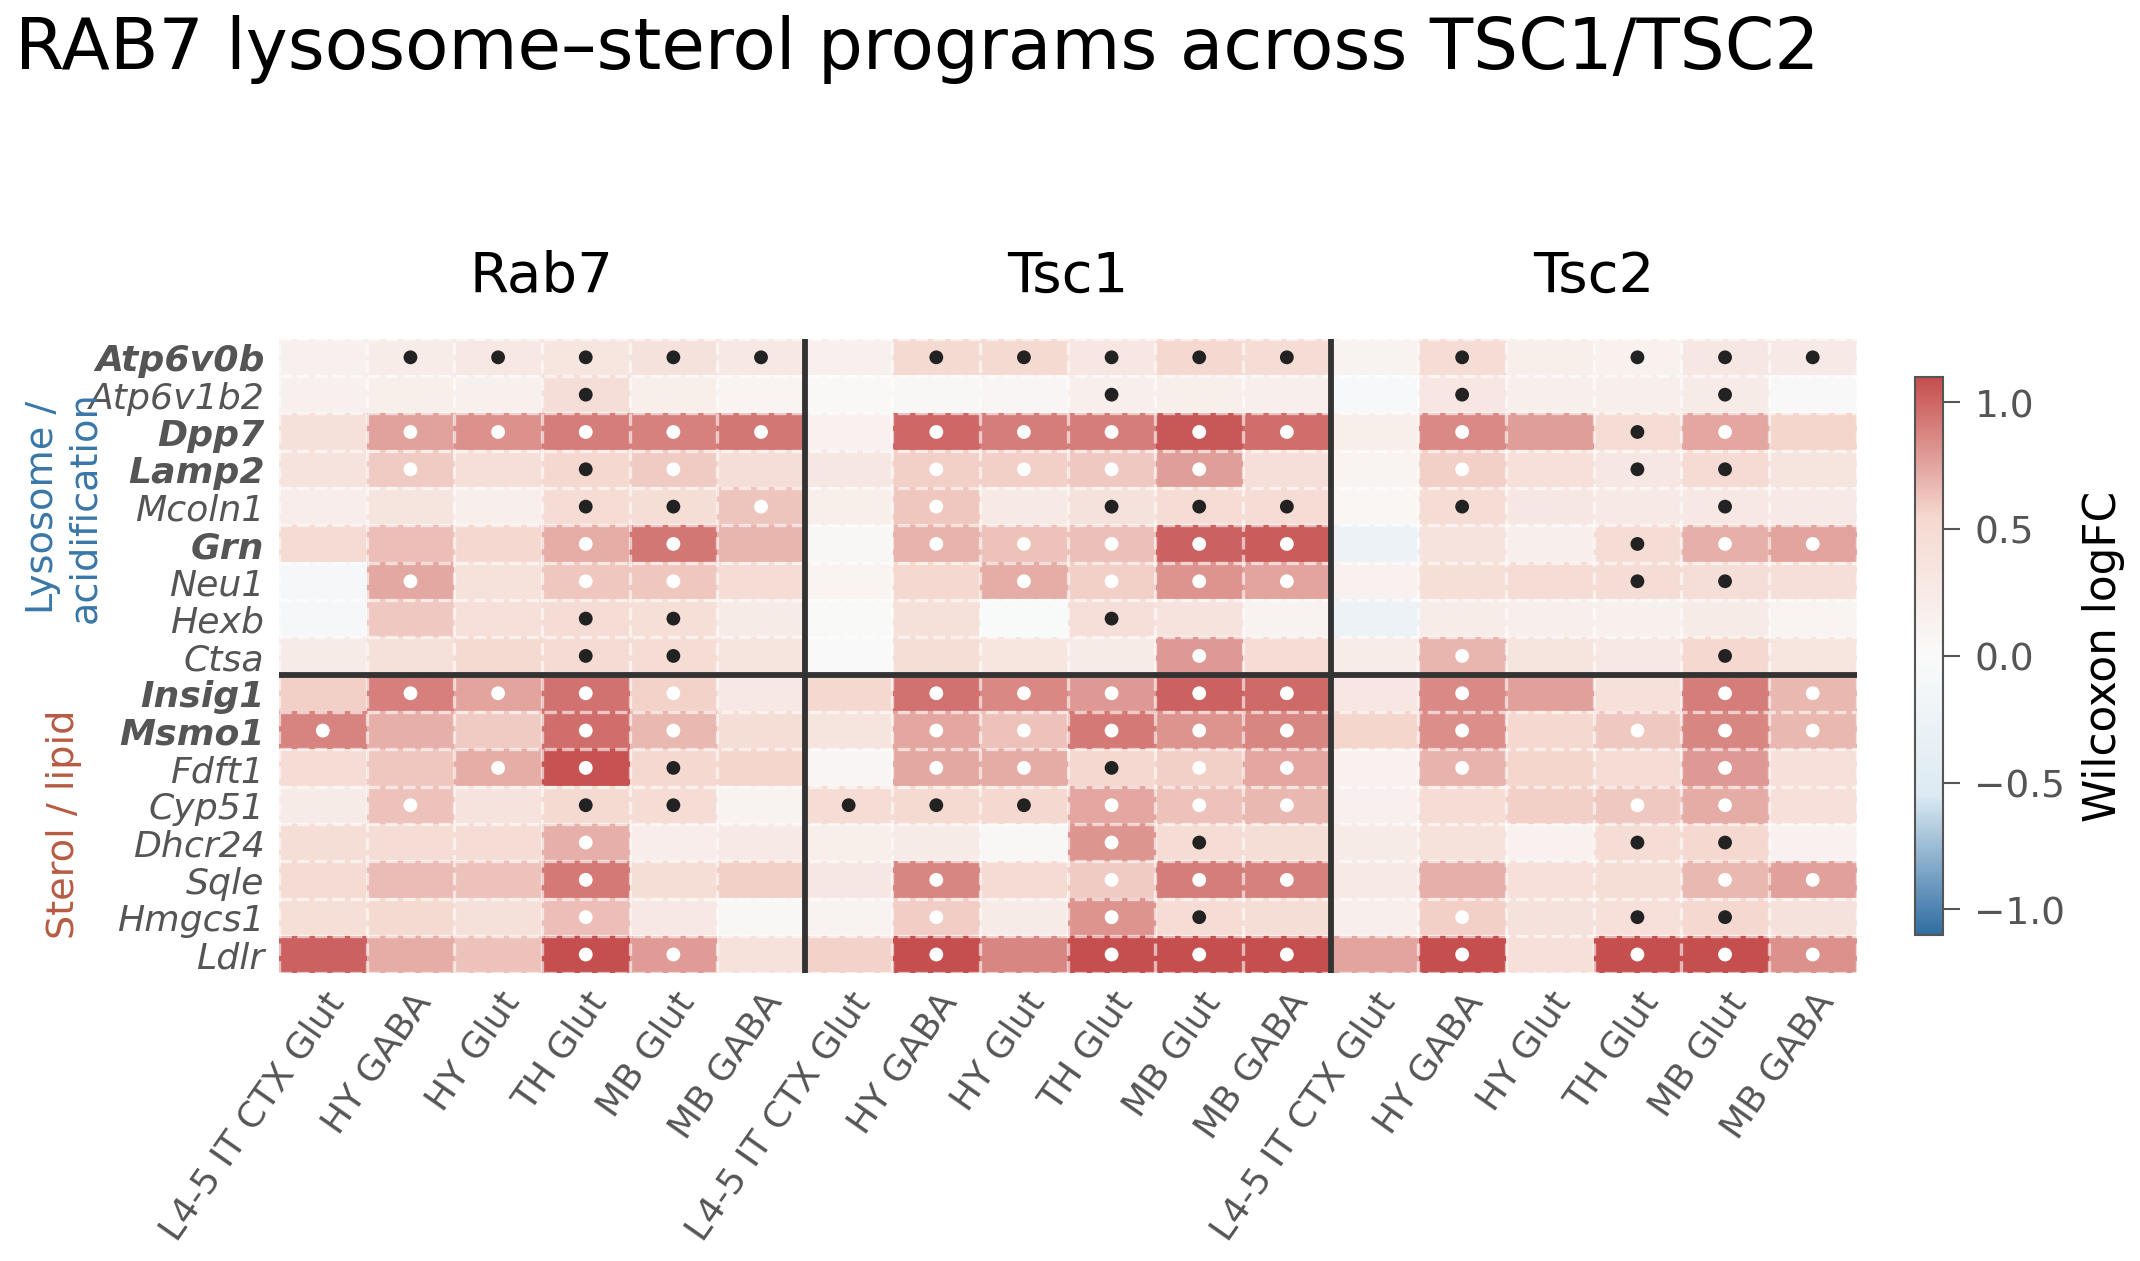

In [13]:
from pathlib import Path
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
OUT = ROOT / 'src/manuscript_figures/fig2/k'
DEG = DEG_PATH
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'pdf.fonttype': 42, 'ps.fonttype': 42})
targets = ['Rab7', 'Tsc1', 'Tsc2']
lysosome = ['Atp6v0b', 'Atp6v1b2', 'Dpp7', 'Lamp2', 'Mcoln1', 'Grn', 'Neu1', 'Hexb', 'Ctsa']
sterol = ['Insig1', 'Msmo1', 'Fdft1', 'Cyp51', 'Dhcr24', 'Sqle', 'Hmgcs1', 'Ldlr']
genes = lysosome + sterol
e010_genes = {'Atp6v0b', 'Dpp7', 'Lamp2', 'Insig1', 'Msmo1', 'Cpeb1', 'Grn'}
groups = ['005 L4-5 IT CTX Glut', '066 CNU-HYa HY GABA', '110 CNU-HYa HY MM Glut', '151 TH Prkcd Grin2c Glut', '155 MB Glut', '191 MB P MY GABA']
short = {'005 L4-5 IT CTX Glut': 'L4-5 IT CTX Glut', '066 CNU-HYa HY GABA': 'HY GABA', '110 CNU-HYa HY MM Glut': 'HY Glut', '151 TH Prkcd Grin2c Glut': 'TH Glut', '155 MB Glut': 'MB Glut', '191 MB P MY GABA': 'MB GABA'}
parts = []
for g in groups:
    parts.append(pq.read_table(DEG, columns=['names', 'gene_target', 'group_name', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', '=', g), ('gene_target', 'in', targets), ('names', 'in', genes)]).to_pandas())
d = pd.concat(parts, ignore_index=True)
cols = pd.MultiIndex.from_product([targets, groups], names=['Perturbation', 'Cell type'])
lfc = d.pivot_table(index='names', columns=['gene_target', 'group_name'], values='logfoldchanges').reindex(index=genes, columns=cols)
fdr = d.pivot_table(index='names', columns=['gene_target', 'group_name'], values='pvals_adj').reindex(index=genes, columns=cols)
cmap = LinearSegmentedColormap.from_list('bio_div', ['#2F6DA3', '#DCEAF2', '#FAFAFA', '#F5D8CF', '#C54E4E'])
lim = max(0.8, float(np.nanpercentile(np.abs(lfc.values), 98)))
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
fig, ax = plt.subplots(figsize=(8.0, 4.7))
fig.subplots_adjust(left=0.19, right=0.89, bottom=0.27, top=0.72)
im = ax.imshow(lfc.values, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(genes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.8)
ax.tick_params(which='minor', bottom=False, left=False)
ax.set_yticks(range(len(genes)), genes, fontsize=8.7, fontstyle='italic')
for label, gene in zip(ax.get_yticklabels(), genes):
    if gene in e010_genes:
        label.set_fontweight('bold')
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels([short[g] for t, g in cols], rotation=55, ha='right', rotation_mode='anchor', fontsize=8.7)
ax.tick_params(axis='x', which='major', length=0, pad=3)
ax.tick_params(axis='y', which='major', length=0)
n_group = len(groups)
for boundary in [n_group - 0.5, 2 * n_group - 0.5]:
    ax.axvline(boundary, color='#333333', lw=1.4)
for x, t in zip([n_group / 2 - 0.5, 1.5 * n_group - 0.5, 2.5 * n_group - 0.5], targets):
    ax.text(x, -1.45, t, ha='center', va='bottom', fontsize=13.5, fontweight='normal')
ax.axhline(len(lysosome) - 0.5, color='#333333', lw=1.4)
ax.text(-2.95, (len(lysosome) - 1) / 2, 'Lysosome /\nacidification', ha='center', va='center', fontsize=9.2, color='#3977A8', rotation=90)
ax.text(-2.95, len(lysosome) + (len(sterol) - 1) / 2, 'Sterol / lipid', ha='center', va='center', fontsize=9.2, color='#B75B43', rotation=90)
for i in range(len(genes)):
    for j in range(len(cols)):
        if pd.notna(fdr.iloc[i, j]) and fdr.iloc[i, j] < 0.1:
            color = 'white' if abs(lfc.iloc[i, j]) > 0.52 * lim else '#222222'
            ax.scatter(j, i, s=11, c=color, edgecolor='none')
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.035, shrink=0.88)
cb.set_label('Wilcoxon logFC', fontsize=10.5)
cb.ax.tick_params(labelsize=9)
fig.suptitle('RAB7 lysosome–sterol programs across TSC1/TSC2', x=0.08, y=0.95, ha='left', fontsize=17)
plt.show()

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


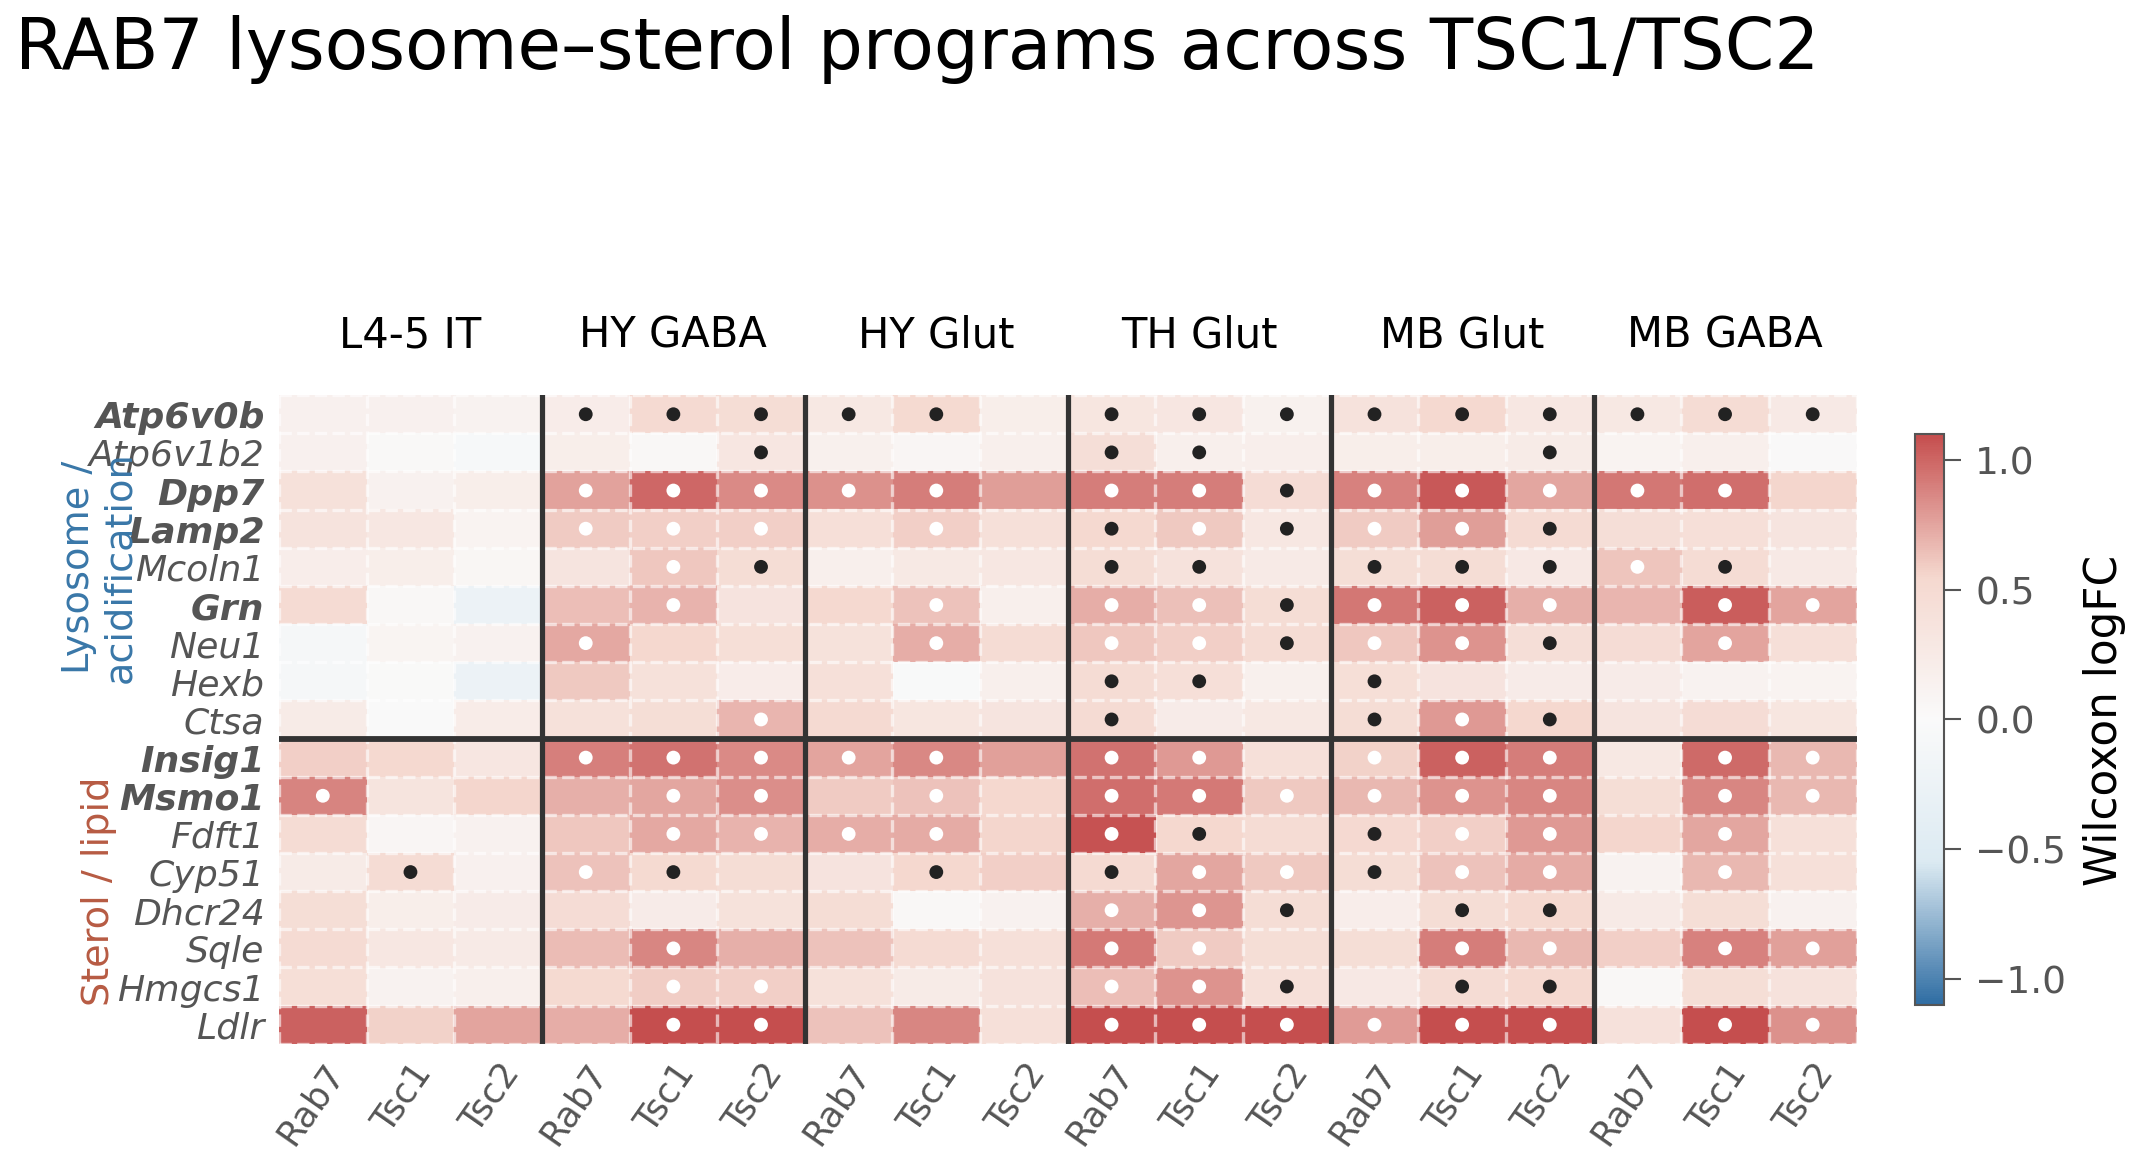

In [14]:
cell_cols = pd.MultiIndex.from_product([groups, targets], names=['Cell type', 'Perturbation'])
lfc_cell = d.pivot_table(index='names', columns=['group_name', 'gene_target'], values='logfoldchanges').reindex(index=genes, columns=cell_cols)
fdr_cell = d.pivot_table(index='names', columns=['group_name', 'gene_target'], values='pvals_adj').reindex(index=genes, columns=cell_cols)
fig, ax = plt.subplots(figsize=(8.0, 4.7))
fig.subplots_adjust(left=0.19, right=0.89, bottom=0.22, top=0.68)
im = ax.imshow(lfc_cell.values, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(np.arange(-0.5, len(cell_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(genes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.8)
ax.tick_params(which='minor', bottom=False, left=False)
ax.set_yticks(range(len(genes)), genes, fontsize=8.7, fontstyle='italic')
for label, gene in zip(ax.get_yticklabels(), genes):
    if gene in e010_genes:
        label.set_fontweight('bold')
ax.set_xticks(np.arange(len(cell_cols)))
ax.set_xticklabels([t for g, t in cell_cols], rotation=55, ha='right', rotation_mode='anchor', fontsize=8.5)
ax.tick_params(axis='x', which='major', length=0, pad=3)
ax.tick_params(axis='y', which='major', length=0)
n_target = len(targets)
for boundary in [n_target * k - 0.5 for k in range(1, len(groups))]:
    ax.axvline(boundary, color='#333333', lw=1.25)
cell_heading = {'005 L4-5 IT CTX Glut': 'L4-5 IT', '066 CNU-HYa HY GABA': 'HY GABA', '110 CNU-HYa HY MM Glut': 'HY Glut', '151 TH Prkcd Grin2c Glut': 'TH Glut', '155 MB Glut': 'MB Glut', '191 MB P MY GABA': 'MB GABA'}
for k, g in enumerate(groups):
    ax.text(k * n_target + (n_target - 1) / 2, -1.52, cell_heading[g], ha='center', va='bottom', fontsize=10.0)
ax.axhline(len(lysosome) - 0.5, color='#333333', lw=1.4)
ax.text(-2.55, (len(lysosome) - 1) / 2, 'Lysosome /\nacidification', ha='center', va='center', fontsize=9.2, color='#3977A8', rotation=90)
ax.text(-2.55, len(lysosome) + (len(sterol) - 1) / 2, 'Sterol / lipid', ha='center', va='center', fontsize=9.2, color='#B75B43', rotation=90)
for i in range(len(genes)):
    for j in range(len(cell_cols)):
        if pd.notna(fdr_cell.iloc[i, j]) and fdr_cell.iloc[i, j] < 0.1:
            color = 'white' if abs(lfc_cell.iloc[i, j]) > 0.52 * lim else '#222222'
            ax.scatter(j, i, s=11, c=color, edgecolor='none')
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.035, shrink=0.88)
cb.set_label('Wilcoxon logFC', fontsize=10.5)
cb.ax.tick_params(labelsize=9)
fig.suptitle('RAB7 lysosome–sterol programs across TSC1/TSC2', x=0.08, y=0.95, ha='left', fontsize=17)
plt.show()

## Figure 2L — Wdr26/Tsc phenocopy

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


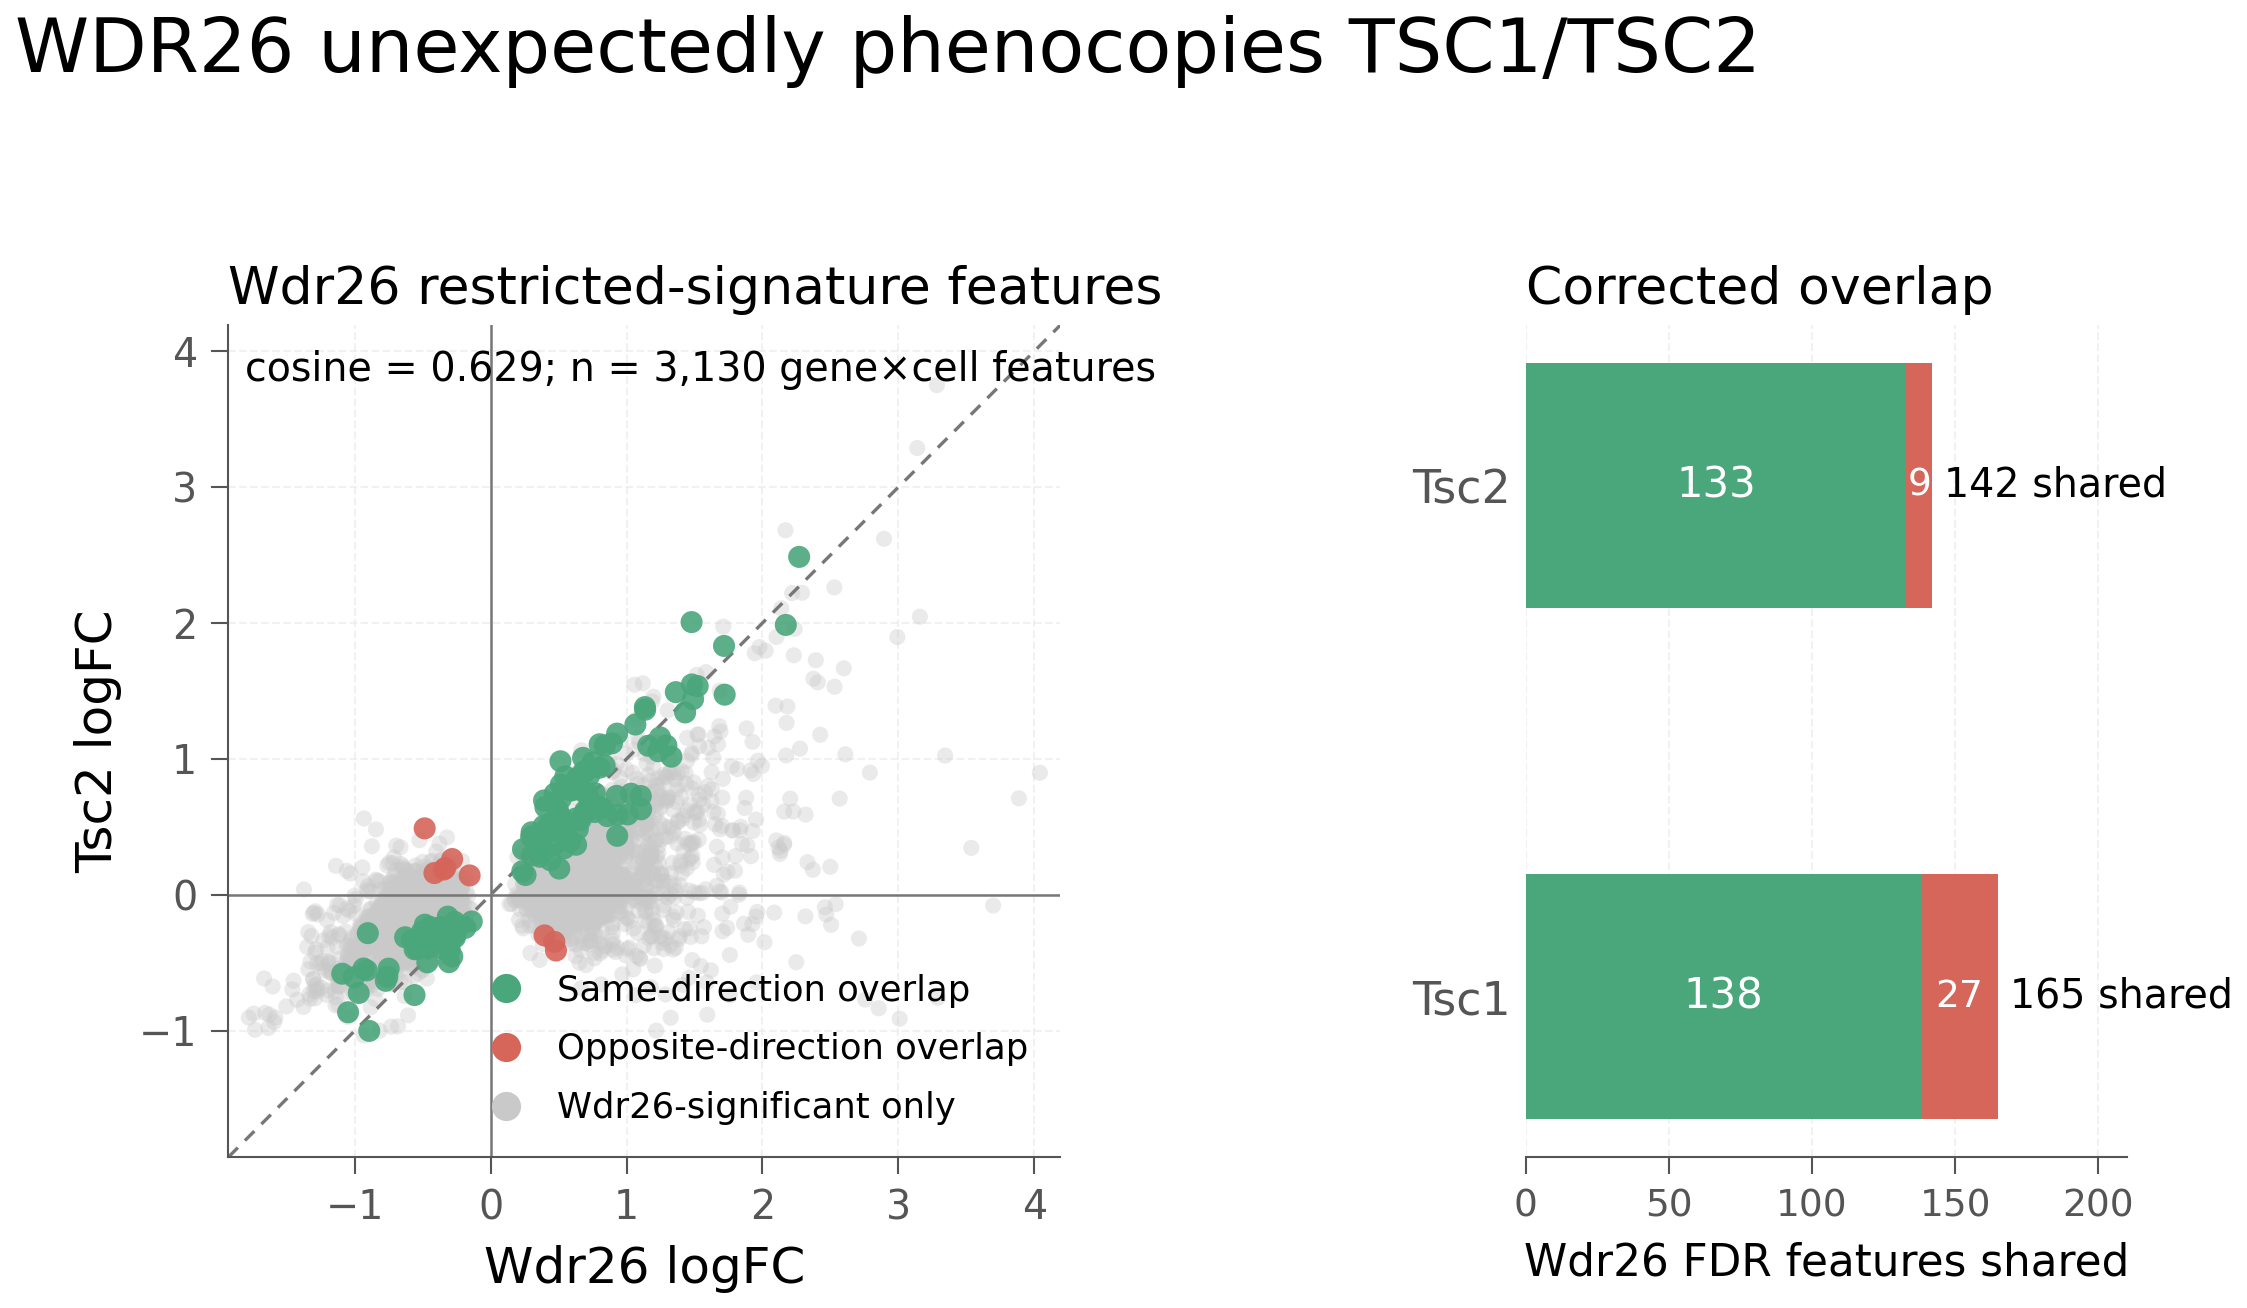

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.spatial.distance import cosine
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
OUT = ROOT / 'src/manuscript_figures/fig2/l'
DEG = DEG_PATH
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})
groups = ['066 CNU-HYa HY GABA', '110 CNU-HYa HY MM Glut', '145 MH-LH TH Glut', '151 TH Prkcd Grin2c Glut', '155 MB Glut', '191 MB P MY GABA', '308 CB GABA']
parts = []
for group in groups:
    parts.append(pq.read_table(DEG, columns=['names', 'gene_target', 'group_name', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', '=', group), ('gene_target', 'in', ['Wdr26', 'Tsc1', 'Tsc2'])]).to_pandas())
raw = pd.concat(parts, ignore_index=True)
w = raw[raw.gene_target.eq('Wdr26') & (raw.pvals_adj < 0.1)].set_index(['group_name', 'names'])[['logfoldchanges']].rename(columns={'logfoldchanges': 'Wdr26_logFC'})

def comparator(target):
    z = raw[raw.gene_target.eq(target)].set_index(['group_name', 'names'])[['logfoldchanges', 'pvals_adj']].reindex(w.index).rename(columns={'logfoldchanges': f'{target}_logFC', 'pvals_adj': f'{target}_FDR'})
    return w.join(z)
t2 = comparator('Tsc2')
t1 = comparator('Tsc1')
restricted_cosine = 1 - cosine(t2.Wdr26_logFC, t2.Tsc2_logFC)
for d, target in [(t2, 'Tsc2'), (t1, 'Tsc1')]:
    shared = d[f'{target}_FDR'] < 0.1
    d['overlap'] = 'Wdr26-significant only'
    d.loc[shared, 'overlap'] = 'Opposite-direction overlap'
    d.loc[shared & (d.Wdr26_logFC * d[f'{target}_logFC'] > 0), 'overlap'] = 'Same-direction overlap'
counts = pd.DataFrame({'target': ['Tsc2', 'Tsc1'], 'same': [133, 138], 'opposite': [9, 27], 'total': [142, 165]})
assert len(t2) == 3130 and round(restricted_cosine, 3) == 0.629
assert [(t2.overlap == 'Same-direction overlap').sum(), (t2.overlap == 'Opposite-direction overlap').sum()] == [133, 9]
assert [(t1.overlap == 'Same-direction overlap').sum(), (t1.overlap == 'Opposite-direction overlap').sum()] == [138, 27]
colors = {'Same-direction overlap': '#4AA67B', 'Opposite-direction overlap': '#D6655A', 'Wdr26-significant only': '#C9C9C9'}
fig = plt.figure(figsize=(8.0, 4.7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 0.75], left=0.1, right=0.96, bottom=0.15, top=0.74, wspace=0.34)
ax = fig.add_subplot(gs[0, 0])
for cls in ['Wdr26-significant only', 'Same-direction overlap', 'Opposite-direction overlap']:
    d = t2[t2.overlap.eq(cls)]
    ax.scatter(d.Wdr26_logFC, d.Tsc2_logFC, s=15 if cls.startswith('Wdr26') else 28, c=colors[cls], edgecolor='none', alpha=0.38 if cls.startswith('Wdr26') else 0.9, zorder=1 if cls.startswith('Wdr26') else 3)
lo = min(t2.Wdr26_logFC.min(), t2.Tsc2_logFC.min()) - 0.15
hi = max(t2.Wdr26_logFC.max(), t2.Tsc2_logFC.max()) + 0.15
ax.plot([lo, hi], [lo, hi], color='#777777', lw=0.8, ls=(0, (4, 3)))
ax.axhline(0, color='#777777', lw=0.6)
ax.axvline(0, color='#777777', lw=0.6)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Wdr26 logFC', fontsize=12)
ax.set_ylabel('Tsc2 logFC', fontsize=12)
ax.set_title('Wdr26 restricted-signature features', loc='left', fontsize=12.5, pad=5)
ax.text(0.02, 0.97, f'cosine = {restricted_cosine:.3f}; n = {len(t2):,} gene×cell features', transform=ax.transAxes, ha='left', va='top', fontsize=9.5)
ax.grid(color='#E9E9E9', lw=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9.5)
legend = [Line2D([0], [0], marker='o', ls='', color=colors[k], markersize=6, label=k) for k in ['Same-direction overlap', 'Opposite-direction overlap', 'Wdr26-significant only']]
ax.legend(handles=legend, loc='lower right', frameon=False, fontsize=8.5, handletextpad=0.45, labelspacing=0.7)
ax2 = fig.add_subplot(gs[0, 1])
y = np.array([1, 0])
ax2.barh(y, counts.same, color=colors['Same-direction overlap'], height=0.48, label='Same direction')
ax2.barh(y, counts.opposite, left=counts.same, color=colors['Opposite-direction overlap'], height=0.48, label='Opposite direction')
for yy, row in zip(y, counts.itertuples()):
    ax2.text(row.same / 2, yy, str(row.same), ha='center', va='center', fontsize=10, color='white')
    ax2.text(row.same + row.opposite / 2, yy, str(row.opposite), ha='center', va='center', fontsize=9, color='white')
    ax2.text(row.total + 4, yy, f'{row.total} shared', ha='left', va='center', fontsize=9.5)
ax2.set_yticks(y, ['Tsc2', 'Tsc1'], fontsize=11)
ax2.set_xlim(0, 210)
ax2.set_xlabel('Wdr26 FDR features shared', fontsize=10.5)
ax2.set_title('Corrected overlap', loc='left', fontsize=12.5, pad=5)
ax2.grid(axis='x', color='#E9E9E9', lw=0.5)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', labelsize=9)
fig.suptitle('WDR26 unexpectedly phenocopies TSC1/TSC2', x=0.08, y=0.96, ha='left', fontsize=18)
plt.show()

## Figure 2M — Tsc2 cerebellar GABA program

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


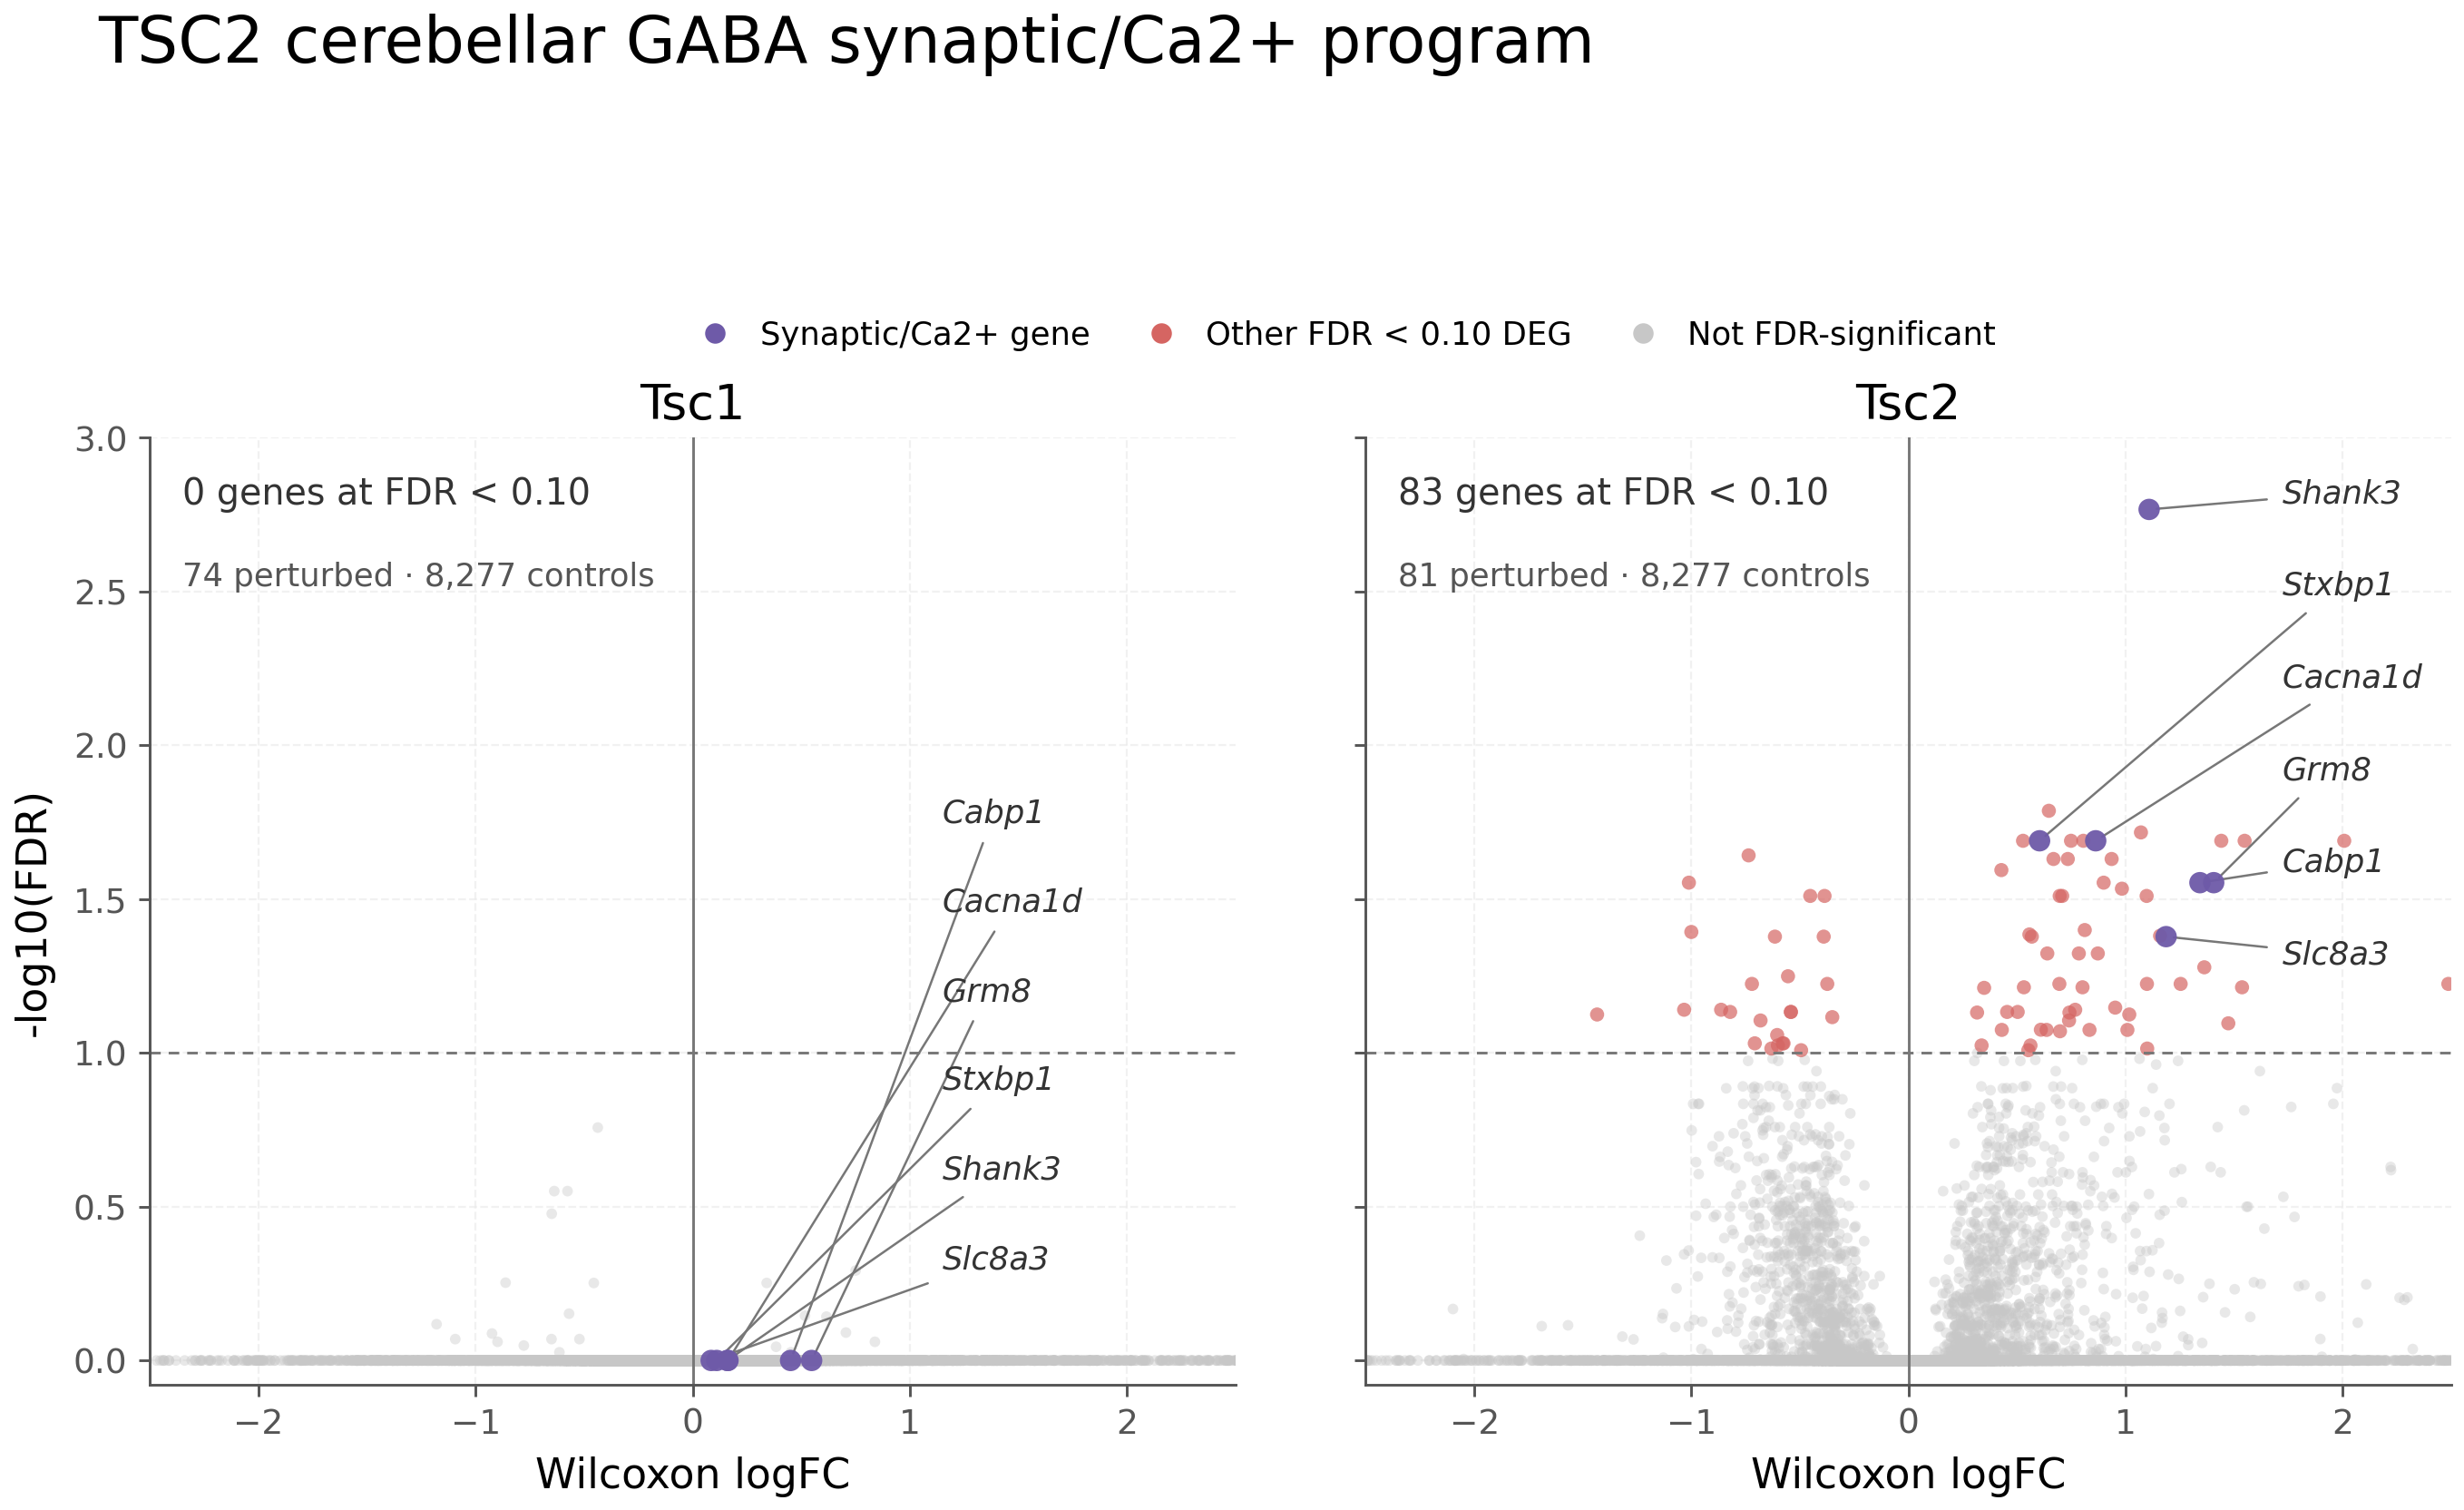

In [16]:
from pathlib import Path
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
OUT = ROOT / 'src/manuscript_figures/fig2/m'
DEG = DEG_PATH
group = '308 CB GABA'
targets = ['Tsc1', 'Tsc2']
program = ['Shank3', 'Stxbp1', 'Cacna1d', 'Grm8', 'Cabp1', 'Slc8a3']
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'pdf.fonttype': 42, 'ps.fonttype': 42})
d = pq.read_table(DEG, columns=['names', 'gene_target', 'group_name', 'logfoldchanges', 'pvals', 'pvals_adj', 'n_pert_matched', 'n_ctrl_matched'], filters=[('group_name', '=', group), ('gene_target', 'in', targets)]).to_pandas()
d['minus_log10_fdr'] = -np.log10(d.pvals_adj.clip(lower=np.nextafter(0, 1)))
d['fdr_sig'] = d.pvals_adj < 0.1
assert d[(d.gene_target == 'Tsc1') & d.fdr_sig].shape[0] == 0
assert d[(d.gene_target == 'Tsc2') & d.fdr_sig].shape[0] == 83
grey = '#C7C7C7'
red = '#D56562'
purple = '#6E5AA8'
dark = '#333333'
fig, axs = plt.subplots(1, 2, figsize=(9.5, 6.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.14, top=0.72, wspace=0.12)
xlim = 2.5
ymax = max(3.0, float(np.nanmax(d.minus_log10_fdr)) * 1.08)
for ax, target in zip(axs, targets):
    z = d[d.gene_target == target].copy()
    named = z.names.isin(program)
    ax.scatter(z.loc[~z.fdr_sig, 'logfoldchanges'], z.loc[~z.fdr_sig, 'minus_log10_fdr'], s=8, c=grey, alpha=0.4, edgecolor='none', rasterized=False)
    ax.scatter(z.loc[z.fdr_sig & ~named, 'logfoldchanges'], z.loc[z.fdr_sig & ~named, 'minus_log10_fdr'], s=14, c=red, alpha=0.7, edgecolor='none')
    ax.scatter(z.loc[named, 'logfoldchanges'], z.loc[named, 'minus_log10_fdr'], s=32, c=purple, alpha=0.95, edgecolor='none', zorder=4)
    if target == 'Tsc2':
        label_xy = {'Shank3': (1.72, 2.82), 'Stxbp1': (1.72, 2.52), 'Cacna1d': (1.72, 2.22), 'Grm8': (1.72, 1.92), 'Cabp1': (1.72, 1.62), 'Slc8a3': (1.72, 1.32)}
        for row in z[named].itertuples():
            ax.annotate(row.names, xy=(row.logfoldchanges, row.minus_log10_fdr), xytext=label_xy[row.names], fontsize=8.5, fontstyle='italic', color=dark, ha='left', va='center', arrowprops=dict(arrowstyle='-', color='#777777', lw=0.6))
    else:
        label_xy = {'Cabp1': (1.15, 1.78), 'Cacna1d': (1.15, 1.49), 'Grm8': (1.15, 1.2), 'Stxbp1': (1.15, 0.91), 'Shank3': (1.15, 0.62), 'Slc8a3': (1.15, 0.33)}
        for row in z[named].itertuples():
            ax.annotate(row.names, xy=(row.logfoldchanges, row.minus_log10_fdr), xytext=label_xy[row.names], fontsize=8.5, fontstyle='italic', color=dark, ha='left', va='center', arrowprops=dict(arrowstyle='-', color='#777777', lw=0.6))
    ax.axvline(0, color='#777777', lw=0.7)
    ax.axhline(1, color='#777777', lw=0.7, ls=(0, (4, 3)))
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(-0.08, ymax)
    n = int(z.fdr_sig.sum())
    n_pert = int(z.n_pert_matched.iloc[0])
    n_ctrl = int(z.n_ctrl_matched.iloc[0])
    ax.set_title(target, fontsize=13, pad=5)
    ax.text(0.03, 0.96, f'{n} genes at FDR < 0.10', transform=ax.transAxes, ha='left', va='top', fontsize=9.5, color=dark)
    ax.text(0.03, 0.87, f'{n_pert} perturbed · {n_ctrl:,} controls', transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#555555')
    ax.set_xlabel('Wilcoxon logFC', fontsize=11, labelpad=4)
    ax.grid(color='#E9E9E9', lw=0.55)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)
    ax.tick_params(labelsize=9, length=3, width=0.7, pad=3)
axs[0].set_ylabel('-log10(FDR)', fontsize=11, labelpad=5)
legend = [Line2D([0], [0], marker='o', ls='', markerfacecolor=purple, markeredgecolor='none', markersize=6, label='Synaptic/Ca2+ gene'), Line2D([0], [0], marker='o', ls='', markerfacecolor=red, markeredgecolor='none', markersize=6, label='Other FDR < 0.10 DEG'), Line2D([0], [0], marker='o', ls='', markerfacecolor=grey, markeredgecolor='none', markersize=6, label='Not FDR-significant')]
fig.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.55, 0.81), frameon=False, ncol=3, fontsize=8.5, handletextpad=0.4, columnspacing=1.2, markerscale=0.9)
fig.suptitle('TSC2 cerebellar GABA synaptic/Ca2+ program', x=0.07, y=0.98, ha='left', fontsize=17)
plt.show()